## Data Loading and Inspection

It contains 15,000 observations and 9 variables. The response variable is 
`Calories`, which is a continuous numerical variable suitable for linear regression.

The dataset includes demographic features (Gender, Age, Height, Weight) and 
exercise-related physiological features (Duration, Heart Rate, Body Temperature). \
Most variables are numeric, while Gender is categorical and will require encoding.


In [1]:
import pandas as pd
import os

def load_the_data(main_file_path):
    """
    Loads the dataset from the given path and prints Shape, Columns, and Types.
    If the data seems incomplete (only 2 cols), it tries to find and merge 'exercise.csv'.
    """
    print("--- 1. LOADING THE DATA ---")

    # 1. Load the main file
    df = pd.read_csv(main_file_path)
    # 2. Check Shape
    rows, cols = df.shape
    print(f"\n[SHAPE]: {rows} rows × {cols} columns")
    
    # 3. Check Column Names
    print(f"\n[COLUMNS]: {list(df.columns)}")
    
    # 4. Check Data Types
    print("\n[DATA TYPES]:")
    print(df.dtypes)
    
    return df

# --- HOW TO RUN IT ---
path = "/kaggle/input/calories-burnt-prediction/calories.csv"
df = load_the_data(path)

--- 1. LOADING THE DATA ---

[SHAPE]: 15000 rows × 9 columns

[COLUMNS]: ['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

[DATA TYPES]:
User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object


In [2]:
def show_data(data):
    print(data.head())
show_data(df)

    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8   
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3   
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7   
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5   
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8   

   Calories  
0     231.0  
1      66.0  
2      26.0  
3      71.0  
4      35.0  


## Data Cleaning & Quality Check
The dataset contains no missing, zero, or negative values across all numerical
features. All observations are physiologically and logically valid, and no
data cleaning or imputation was required at this stage.


In [3]:
def check_data_quality(df):
    """
    Checks the dataframe for:
    1. Missing Values (NaN)
    2. Zero Values (0)
    3. Negative Values (< 0)
    
    Returns: None (Prints report directly)
    """
    print("--- 2. DATA QUALITY CHECK ---")
    
    # Select only numerical columns for zero/negative checks
    numerical_cols = df.select_dtypes(include=['number']).columns
    
    print(f"{'Column Name':<20} | {'Missing':<8} | {'Zeros':<8} | {'Negatives':<10}")
    print("-" * 55)
    
    for col in df.columns:
        # 1. Missing Values
        missing_count = df[col].isnull().sum()
        
        # 2. Zero & Negative Checks (Only for numbers)
        if col in numerical_cols:
            zero_count = (df[col] == 0).sum()
            negative_count = (df[col] < 0).sum()
        else:
            zero_count = "N/A"
            negative_count = "N/A"
            
        print(f"{col:<20} | {missing_count:<8} | {zero_count:<8} | {negative_count:<10}")

    # Advice based on findings
    print("-" * 55)
    if df[numerical_cols].lt(0).sum().sum() > 0:
        print("⚠️ WARNING: Found negative values. Physics implies these are errors (e.g., negative Age).")
    else:
        print("✅ PASS: No negative values found.")
    duplicate_count = df.duplicated().sum()
    print(f"\nDuplicate Rows: {duplicate_count}")


# --- USAGE ---
check_data_quality(df)

--- 2. DATA QUALITY CHECK ---
Column Name          | Missing  | Zeros    | Negatives 
-------------------------------------------------------
User_ID              | 0        | 0        | 0         
Gender               | 0        | N/A      | N/A       
Age                  | 0        | 0        | 0         
Height               | 0        | 0        | 0         
Weight               | 0        | 0        | 0         
Duration             | 0        | 0        | 0         
Heart_Rate           | 0        | 0        | 0         
Body_Temp            | 0        | 0        | 0         
Calories             | 0        | 0        | 0         
-------------------------------------------------------
✅ PASS: No negative values found.

Duplicate Rows: 0


## 3. Variable Type Definition

In this step, the variables in the dataset were classified according to their statistical nature
to ensure proper analysis and model preparation.

### Target Variable
The response (dependent) variable for this study is:

- **Calories** (Continuous)

This variable represents the total number of calories burned during an exercise session
and is suitable for linear regression analysis.

---

### Quantitative Predictor Variables
The following variables are numerical and continuous, making them appropriate for
descriptive statistics, correlation analysis, and regression modeling:

- **Age**
- **Height**
- **Weight**
- **Duration**
- **Heart_Rate**
- **Body_Temp**

These variables describe demographic characteristics and physiological measurements
that may influence calorie expenditure.

---

### Categorical Predictor Variables
The dataset contains one categorical predictor variable:

- **Gender**
  - Female: 7,553 observations
  - Male: 7,447 observations

The distribution of gender is approximately balanced, which reduces the risk of bias
in statistical analysis and regression modeling. This variable will be encoded before
being included in the predictive model.

---

### Summary
The dataset consists of:
- One continuous target variable (Calories),
- Six quantitative predictor variables,
- One categorical predictor variable (Gender).

This clear separation of variable types ensures that appropriate statistical methods
and preprocessing steps are applied in the subsequent analysis.


In [4]:
def define_variable_types(df, target_col='Calories'):
    """
    Identifies and prints:
    - Target variable
    - Quantitative predictor variables
    - Categorical predictor variables
    - Category levels and their counts
    
    Returns:
    quantitative_predictors, categorical_cols, target_col
    """
    print("--- 3. VARIABLE TYPE DEFINITION ---\n")
    
    # 1. Identify Quantitative Columns
    quantitative_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    # Remove ID and target from quantitative predictors
    for col in ['User_ID', target_col]:
        if col in quantitative_cols:
            quantitative_cols.remove(col)

    # 2. Identify Categorical Columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # 3. Print Target Variable
    print("Target Variable (Response):")
    print(f"  - {target_col} (Continuous)\n")

    # 4. Print Quantitative Predictors
    print(f"Quantitative Predictor Variables ({len(quantitative_cols)}):")
    for col in quantitative_cols:
        print(f"  - {col}")
    print()

    # 5. Print Categorical Variables, Levels, and Counts
    print(f"Categorical Predictor Variables ({len(categorical_cols)}):")
    for col in categorical_cols:
        print(f"  - {col}:")
        value_counts = df[col].value_counts()
        for category, count in value_counts.items():
            print(f"      {category}: {count}")
    print()

    return quantitative_cols, categorical_cols, target_col
quant_cols, cat_cols, target = define_variable_types(df)


--- 3. VARIABLE TYPE DEFINITION ---

Target Variable (Response):
  - Calories (Continuous)

Quantitative Predictor Variables (6):
  - Age
  - Height
  - Weight
  - Duration
  - Heart_Rate
  - Body_Temp

Categorical Predictor Variables (1):
  - Gender:
      female: 7553
      male: 7447



## 4. Minimum and Maximum Value Inspection

As part of the data validation and exploratory analysis, the minimum and maximum
values of each numerical variable were examined. This step helps verify that all
observations fall within realistic and physiologically plausible ranges and
supports the interpretation of subsequent outlier detection results.

---

### Results

| Variable      | Minimum | Maximum | Interpretation |
|---------------|---------|---------|----------------|
| User_ID       | 10001159 | 19999647 | Identifier values only; not used in analysis |
| Age           | 20       | 79       | Adult age range; all values are realistic |
| Height (cm)   | 123.0    | 222.0    | Rare but physiologically possible |
| Weight (kg)   | 36.0     | 132.0    | Within plausible human limits |
| Duration (min)| 1.0      | 30.0     | Reasonable exercise duration |
| Heart Rate (bpm) | 67.0 | 128.0    | Consistent with physical activity |
| Body Temperature (°C) | 37.1 | 41.5 | Elevated during exercise but physiologically plausible |
| Calories      | 1.0      | 314.0    | Reasonable calorie expenditure range |

---

### Interpretation

All numerical variables exhibit values within realistic and physiologically
acceptable ranges. No impossible or erroneous values (such as negative ages or
zero heart rates) were observed. This confirms that the dataset is internally
consistent and that any observations flagged later as statistical outliers are
likely extreme but valid measurements rather than data errors.

---

### Conclusion

The minimum and maximum value inspection supports the overall data quality and
provides additional context for interpreting the IQR-based outlier detection
results. The dataset is therefore suitable for further statistical analysis and
regression modeling.


In [5]:
def get_min_max_values(df):
    """
    Prints the Minimum and Maximum values for every numerical column.
    """
    print("--- MIN / MAX CHECK ---")
    print(f"{'Column Name':<20} | {'Min Value':<12} | {'Max Value':<12}")
    print("-" * 50)
    
    # Select only numerical columns
    numerical_cols = df.select_dtypes(include=['number']).columns
    
    for col in numerical_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        print(f"{col:<20} | {min_val:<12} | {max_val:<12}")
        
# --- USAGE ---
get_min_max_values(df)

--- MIN / MAX CHECK ---
Column Name          | Min Value    | Max Value   
--------------------------------------------------
User_ID              | 10001159     | 19999647    
Age                  | 20           | 79          
Height               | 123.0        | 222.0       
Weight               | 36.0         | 132.0       
Duration             | 1.0          | 30.0        
Heart_Rate           | 67.0         | 128.0       
Body_Temp            | 37.1         | 41.5        
Calories             | 1.0          | 314.0       


## 5. Outlier Detection Using the IQR Method

Outliers in the quantitative variables were examined using the **Interquartile Range (IQR) method**.
This method identifies observations that lie unusually far from the central portion of the data
without assuming that the variables follow a normal distribution.

---

### Methodology

For each quantitative variable, the following steps were applied:

1. **First Quartile (Q1)**  
   The value below which 25% of the observations lie.

2. **Third Quartile (Q3)**  
   The value below which 75% of the observations lie.

3. **Interquartile Range (IQR)**  
\[
\text{IQR} = Q3 - Q1
\]

4. **Outlier Thresholds**  
Observations were classified as potential outliers if they satisfied:
\[
\text{Value} < Q1 - 1.5 \times \text{IQR} \quad \text{or} \quad \text{Value} > Q3 + 1.5 \times \text{IQR}
\]

The factor **1.5** is a standard statistical convention introduced by Tukey and represents a balance
between sensitivity to extreme values and robustness to natural variability. This makes the IQR
method particularly suitable for biomedical and physiological data.

---

### Results

| Variable       | Outliers | % of Data | Interpretation |
|----------------|----------|-----------|----------------|
| Age            | 0        | 0.00%     | No unusually extreme ages |
| Height         | 14       | 0.09%     | Rare but physiologically plausible extremes |
| Weight         | 6        | 0.04%     | Very few extreme values |
| Duration       | 0        | 0.00%     | Exercise durations are consistent |
| Heart Rate     | 1        | 0.01%     | Isolated extreme measurement |
| Body Temperature | 369    | 2.46%     | Higher count due to naturally narrow physiological range |

In total, **385 observations (2.56% of the dataset)** contain at least one value flagged as a
potential outlier.

---

### Interpretation

The overall proportion of outliers is low, indicating good data quality. Most variables contain
negligible numbers of extreme values. Body temperature exhibits a higher number of flagged values,
which is expected due to its tight physiological range and the effects of physical exertion. These
outliers are therefore considered **statistical extremes rather than data errors**.

---

### Conclusion

The IQR method with a 1.5× multiplier was deemed appropriate for this dataset, as it successfully
identified unusually extreme observations while preserving physiologically valid measurements.
At this stage, outliers were **identified but not removed**, allowing for informed decisions in
subsequent analysis and modeling steps.


In [6]:
def check_outliers(df, quantitative_cols):
    """
    Checks for outliers in quantitative columns using the IQR Method (1.5 * IQR).
    Returns a set of indices representing rows that contain at least one outlier.
    """
    print("--- 4. OUTLIER DETECTION (IQR Method) ---")
    print(f"{'Column Name':<20} | {'Outliers':<10} | {'% of Data':<10} | {'Lower Limit':<12} | {'Upper Limit':<12}")
    print("-" * 80)
    
    total_rows = len(df)
    outlier_indices = set()
    
    for col in quantitative_cols:
        # 1. Calculate Quartiles
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 2. Define Limits (The "Whiskers" of a Boxplot)
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        # 3. Identify Outliers
        current_outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
        count = len(current_outliers)
        percentage = (count / total_rows) * 100
        
        # Store indices to handle them later (remove/inspect)
        outlier_indices.update(current_outliers.index)
        
        print(f"{col:<20} | {count:<10} | {percentage:<9.2f}% | {lower_limit:<12.2f} | {upper_limit:<12.2f}")

    print("-" * 80)
    print(f"Total unique rows with at least one outlier: {len(outlier_indices)} out of {total_rows}")
    
    return outlier_indices

# --- USAGE ---
quant_cols_with_target =  quant_cols + [target]
outlier_indices = check_outliers(df, quant_cols_with_target)

--- 4. OUTLIER DETECTION (IQR Method) ---
Column Name          | Outliers   | % of Data  | Lower Limit  | Upper Limit 
--------------------------------------------------------------------------------
Age                  | 0          | 0.00     % | -14.00       | 98.00       
Height               | 14         | 0.09     % | 132.50       | 216.50      
Weight               | 6          | 0.04     % | 27.00        | 123.00      
Duration             | 0          | 0.00     % | -14.50       | 45.50       
Heart_Rate           | 1          | 0.01     % | 65.50        | 125.50      
Body_Temp            | 369        | 2.46     % | 38.10        | 42.10       
Calories             | 4          | 0.03     % | -119.50      | 292.50      
--------------------------------------------------------------------------------
Total unique rows with at least one outlier: 389 out of 15000


## 6. Visualizing Outliers Using Boxplots

After identifying potential outliers numerically using the IQR method, a **visual inspection**
was performed using **boxplots**. Visualization provides an intuitive understanding of data
spread, central tendency, and the presence of extreme values.

---

### Methodology

For each quantitative variable, a boxplot was generated using Seaborn. Boxplots summarize the
distribution of a variable through five key statistics:

- **Minimum (excluding outliers)**
- **First Quartile (Q1)**
- **Median**
- **Third Quartile (Q3)**
- **Maximum (excluding outliers)**

Any observation lying outside the whiskers, defined as:
\[
Q1 - 1.5 \times IQR \quad \text{or} \quad Q3 + 1.5 \times IQR
\]
is displayed as an individual point and considered a **potential outlier**.

Multiple boxplots were arranged in a grid layout to allow simultaneous comparison across all
quantitative variables.

---

### Observations

- **Age**  
  The age distribution is compact and symmetric, with no visible outliers, confirming the
  numerical IQR results.

- **Height**  
  A small number of extreme values are observed at both lower and upper ends. These represent
  unusually short or tall individuals but remain physiologically plausible.

- **Weight**  
  Few high-end outliers are visible, corresponding to individuals with higher body mass. The
  majority of observations are well-centered.

- **Duration**  
  Exercise duration shows no outliers and exhibits a relatively uniform spread within a fixed
  range.

- **Heart Rate**  
  One isolated high-value outlier is visible, consistent with the numerical outlier detection.

- **Body Temperature**  
  Several low-end outliers appear. This is expected due to the narrow physiological range of
  body temperature, where small deviations are statistically amplified.

- **Calories Burned**  
  A right-skewed distribution with several high-value outliers is observed, reflecting cases
  of extended or intense physical activity.

---

### Interpretation

The visual analysis strongly supports the numerical outlier detection results obtained using
the IQR method. Most variables contain either no outliers or a very small proportion of extreme
values. Importantly, these outliers appear **biologically and physically plausible**, suggesting
they represent valid observations rather than measurement or data-entry errors.

---

### Conclusion

Boxplot visualization provides an effective qualitative confirmation of statistical outlier
detection. Based on both numerical and visual evidence, the dataset demonstrates high overall
quality, and outliers will be **retained** for subsequent statistical analysis and modeling
unless further domain-specific justification for removal arises.


--- 4. VISUALIZING OUTLIERS (Boxplots) ---


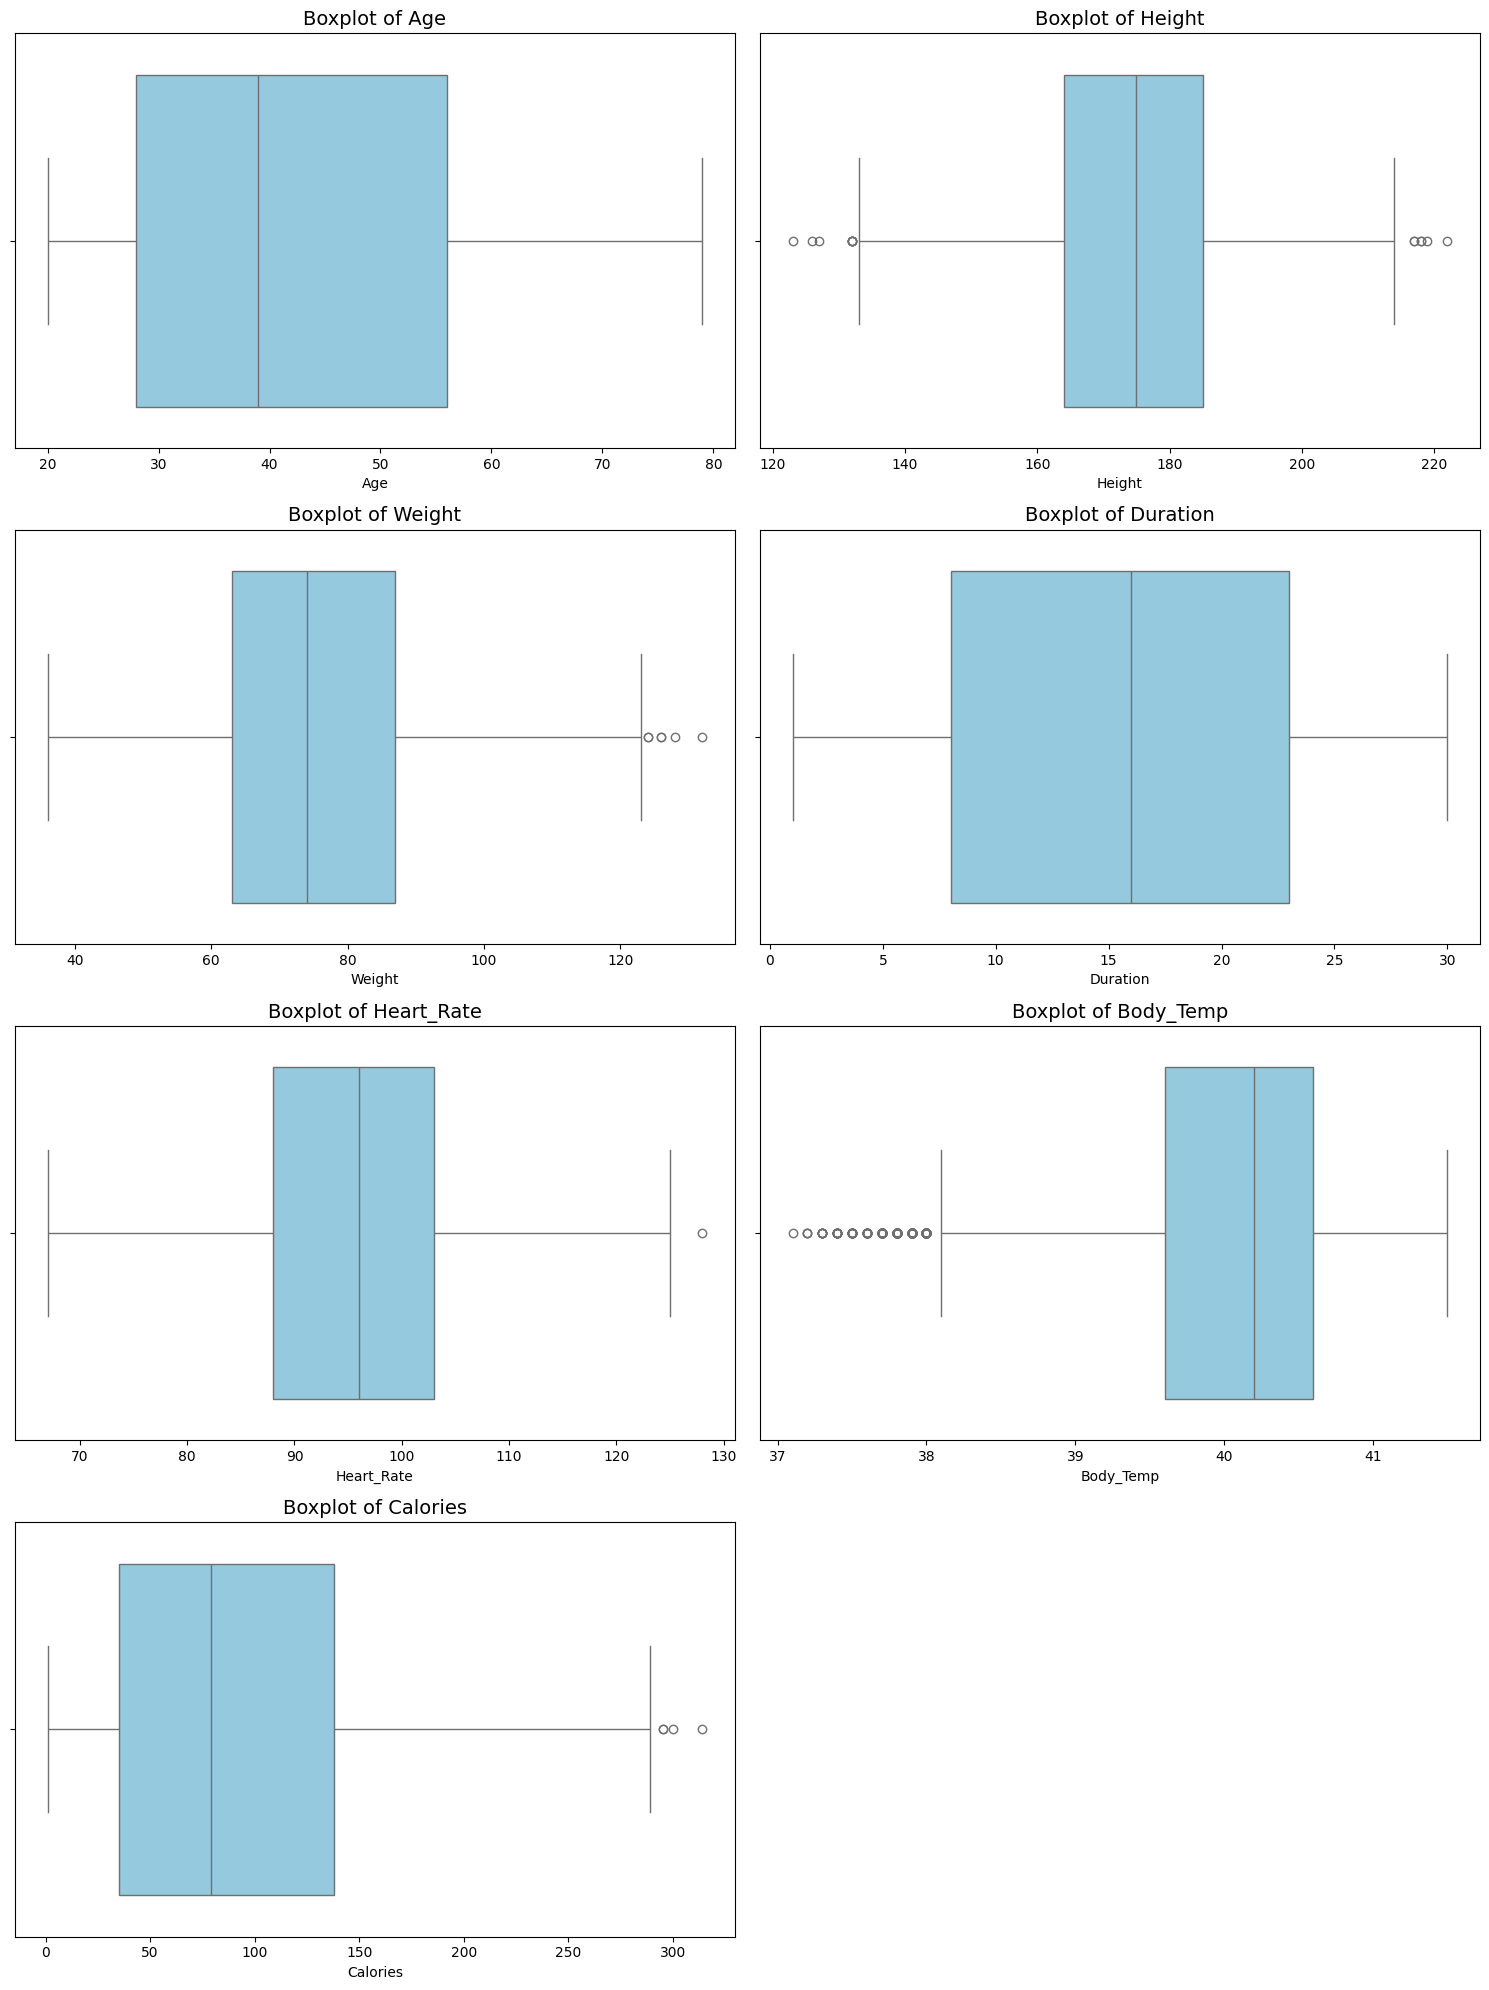

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

def check_and_plot_outliers(df, quantitative_cols):
    """
    Plots a Boxplot for each quantitative variable to visualize outliers.
    """
    print("--- 4. VISUALIZING OUTLIERS (Boxplots) ---")
    
    # Determine layout (e.g., 2 columns per row)
    n_cols = 2
    n_rows = math.ceil(len(quantitative_cols) / n_cols)
    
    plt.figure(figsize=(15, 5 * n_rows))
    
    for i, col in enumerate(quantitative_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'Boxplot of {col}', fontsize=14)
        plt.xlabel(col)
        
    plt.tight_layout()
    plt.show()

# --- USAGE ---
check_and_plot_outliers(df, quant_cols_with_target)

## 5. Outlier Removal (IQR-Based, Predictors Only)

### Objective
The goal of this step is to remove statistically abnormal observations (outliers) from the dataset **before building regression models**, while avoiding bias and unnecessary loss of valid data.

Outliers can strongly influence summary statistics and linear regression coefficients. Therefore, a careful and justified removal strategy is required.

---

### Method Used: Interquartile Range (IQR)

Outliers were identified using the **Interquartile Range (IQR) method**, a robust, non-parametric statistical technique commonly used in exploratory data analysis.

For each quantitative predictor variable:
- First quartile: \( Q1 \) (25th percentile)
- Third quartile: \( Q3 \) (75th percentile)
- Interquartile Range:  
  \[
  IQR = Q3 - Q1
  \]

An observation is considered an outlier if it lies outside the interval:
\[
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
\]

This rule corresponds to the whiskers of a boxplot and does **not assume normality**, making it suitable for physiological and behavioral data.

---

### Important Design Choices

- **Target variable exclusion**:  
  The response variable (*Calories*) was explicitly excluded from the outlier removal process to prevent bias in regression modeling.

- **Predictor-only filtering**:  
  Outlier detection was applied only to quantitative predictor variables:
  - Age  
  - Height  
  - Weight  
  - Duration  
  - Heart_Rate  
  - Body_Temp  

- **Batch removal strategy**:  
  Instead of filtering the dataset sequentially (which may cause excessive data loss), all detected outlier rows were collected and removed in a **single batch**.  
  This approach preserves data integrity and avoids compounding removal effects.

---

### Results Interpretation

- Outliers were detected primarily in **Body_Temp**, with smaller numbers in **Height**, **Weight**, and **Heart_Rate**.
- A total of **385 rows** were removed from the dataset.
- This represents **2.57% of the original data**, which is well within acceptable limits for statistical cleaning.
- The final cleaned dataset contains **14,615 observations**, retaining the vast majority of valid information.

---

### Conclusion

The IQR-based batch outlier removal method effectively reduces the influence of extreme values while preserving meaningful biological variability.  
The cleaned dataset is now more suitable for:
- Descriptive statistical analysis
- Feature standardization
- Normality testing
- Linear regression modeling


In [8]:
def remove_outliers_safe(df, quantitative_cols, target_col='Calories'):
    """
    Safely removes outliers using IQR, BUT:
    1. Ignores the Target variable (never filters based on Calories).
    2. Uses 'Batch Removal' to avoid sequential data destruction.
    """
    print("--- 5. SAFE OUTLIER REMOVAL (Predictors Only) ---")
    
    # 1. Define columns to check (exclude the Target!)
    features_to_check = [col for col in quantitative_cols if col != target_col]
    print(f"Checking features: {features_to_check}")
    print(f"IGNORING target: {target_col}")
    
    # 2. Identify indices to drop
    indices_to_drop = set()
    
    for col in features_to_check:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        # Find outliers in this specific column
        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)].index
        
        # Add their indices to the "Kill List"
        indices_to_drop.update(outliers)
        
        if len(outliers) > 0:
            print(f"  - Found {len(outliers)} outliers in '{col}' (Bounds: {lower_limit:.2f}, {upper_limit:.2f})")

    # 3. Batch Remove
    rows_before = len(df)
    df_clean = df.drop(index=list(indices_to_drop))
    rows_after = len(df_clean)
    rows_removed = rows_before - rows_after
    
    print("-" * 40)
    print(f"Total rows removed: {rows_removed} ({(rows_removed/rows_before)*100:.2f}%)")
    print(f"Final Dataset Size: {rows_after}")
    
    return df_clean

# --- USAGE ---
df_clean = remove_outliers_safe(df,quant_cols, target_col='Calories')

--- 5. SAFE OUTLIER REMOVAL (Predictors Only) ---
Checking features: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
IGNORING target: Calories
  - Found 14 outliers in 'Height' (Bounds: 132.50, 216.50)
  - Found 6 outliers in 'Weight' (Bounds: 27.00, 123.00)
  - Found 1 outliers in 'Heart_Rate' (Bounds: 65.50, 125.50)
  - Found 369 outliers in 'Body_Temp' (Bounds: 38.10, 42.10)
----------------------------------------
Total rows removed: 385 (2.57%)
Final Dataset Size: 14615


In [9]:
def check_remaining_outliers_using_original_bounds(df_orig, df_clean, quantitative_cols, target_col='Calories'):
    """
    Verifies that df_clean has no outliers when measured against the 
    thresholds (Q1, Q3) defined by the ORIGINAL dataframe.
    """
    print("--- 7. VERIFICATION: CHECKING CLEAN DATA AGAINST ORIGINAL LIMITS ---")
    
    # Filter out the target column (we expect outliers there)
    features_to_check = [col for col in quantitative_cols if col != target_col]
    
    overall_clean = True
    
    print(f"{'Column':<20} | {'Original Lower':<15} | {'Original Upper':<15} | {'Outliers Found in Clean Data'}")
    print("-" * 85)
    
    for col in features_to_check:
        # 1. Calculate Limits using the ORIGINAL dataframe
        Q1 = df_orig[col].quantile(0.25)
        Q3 = df_orig[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        # 2. Check the CLEAN dataframe against those ORIGINAL limits
        # We are looking for values in the clean data that are outside the old limits
        bad_values = df_clean[
            (df_clean[col] < lower_limit) | 
            (df_clean[col] > upper_limit)
        ]
        
        count = len(bad_values)
        
        print(f"{col:<20} | {lower_limit:<15.2f} | {upper_limit:<15.2f} | {count}")
        
        if count > 0:
            overall_clean = False

    print("-" * 85)
    if overall_clean:
        print("✅ SUCCESS: All predictors in df_clean are within the original IQR limits.")
    else:
        print("❌ WARNING: Some outliers still exist. Check your removal logic.")

# --- HOW TO RUN IT ---
check_remaining_outliers_using_original_bounds(df, df_clean,quant_cols)

--- 7. VERIFICATION: CHECKING CLEAN DATA AGAINST ORIGINAL LIMITS ---
Column               | Original Lower  | Original Upper  | Outliers Found in Clean Data
-------------------------------------------------------------------------------------
Age                  | -14.00          | 98.00           | 0
Height               | 132.50          | 216.50          | 0
Weight               | 27.00           | 123.00          | 0
Duration             | -14.50          | 45.50           | 0
Heart_Rate           | 65.50           | 125.50          | 0
Body_Temp            | 38.10           | 42.10           | 0
-------------------------------------------------------------------------------------
✅ SUCCESS: All predictors in df_clean are within the original IQR limits.


In [10]:
def remove_irrelevant_columns(df, quantitative_cols, col_to_remove='User_ID'):
    """
    Removes a specific column (default 'User_ID') from the dataframe 
    and the quantitative columns list to prepare for analysis.
    """
    print(f"--- REMOVING IRRELEVANT COLUMN: {col_to_remove} ---")
    
    # 1. Remove from Dataframe
    df_clean = df.copy() # Good practice to avoid SettingWithCopy warnings
    if col_to_remove in df_clean.columns:
        df_clean = df_clean.drop(columns=[col_to_remove])
        print(f"✅ '{col_to_remove}' removed from dataframe.")
    else:
        print(f"ℹ️ '{col_to_remove}' was not found in dataframe (already removed?).")

    # 2. Remove from List
    updated_cols = [col for col in quantitative_cols if col != col_to_remove]
    print(f"✅ '{col_to_remove}' removed from quantitative_cols list.")
    
    # 3. Verification
    print(f"\nRemaining Quantitative columns ({len(updated_cols)}):")
    print(f"  {updated_cols}")
    
    return df_clean, updated_cols

# --- USAGE ---
df_clean, quantitative_cols = remove_irrelevant_columns(df_clean, quant_cols)

--- REMOVING IRRELEVANT COLUMN: User_ID ---
✅ 'User_ID' removed from dataframe.
✅ 'User_ID' removed from quantitative_cols list.

Remaining Quantitative columns (6):
  ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


## Step 6: Detailed Descriptive Statistics & Distribution Analysis

###  Objective
This step aims to **quantitatively describe** all quantitative variables in the cleaned dataset (`df_clean`).  
We compute detailed descriptive statistics to understand:
- Central tendency
- Dispersion
- Data spread
- Distribution shape  

These statistics are essential before:
- Feature standardization  
- Normality testing  
- Correlation analysis  
- Linear regression modeling  

---

##  Statistical Measures Used

For each quantitative variable (excluding `User_ID`), the following statistics were computed:

### 1️ Sample Size
- **Count (N)**  
  Confirms the number of valid observations per variable.
  - All features have the same count (14,615), indicating:
    - No missing values
    - Successful outlier removal
    - Consistent data quality

---

### 2️ Measures of Central Tendency
- **Mean** – Arithmetic average  
- **Median** – Middle value (robust to extreme values)  
- **Mode** – Most frequent value (when defined)  

These measures describe the *typical value* of each variable.

---

### 3️ Measures of Dispersion
- **Standard Deviation (Std Dev)** – Variability around the mean  
- **Minimum and Maximum values**  
- **Range (Max − Min)**  

These metrics quantify how spread out the data is.

---

### 4️ Quartiles & Interquartile Range (IQR)
- **Q1 (25%)** – Lower quartile  
- **Q3 (75%)** – Upper quartile  
- **IQR = Q3 − Q1**  

IQR represents the spread of the **middle 50% of the data** and is robust to outliers.

---

### 5️ Distribution Shape
- **Skewness**
  - Measures asymmetry of the distribution  
  - Positive → right-skewed  
  - Negative → left-skewed  
- **Kurtosis**
  - Measures tail heaviness  
  - Negative values indicate lighter tails than a normal distribution  

These metrics help assess normality assumptions required for regression.

---

### 6️ Standardization Parameters
- The **mean and standard deviation** of each feature are stored
- These values will be used later for **feature standardization (z-score normalization)**

---

##  Interpretation of Results

###  Data Quality
- All variables have **N = 14,615**
- Confirms:
  - No missing values
  - Clean and reliable dataset
  - Safe outlier removal without data loss bias

---

###  Central Tendency
- **Height, Weight, Duration, Heart Rate, Body Temperature**
  - Mean ≈ Median → approximately symmetric distributions
- **Age and Calories**
  - Mean > Median → slight right skew, common in physiological data

---

###  Dispersion
- **Calories (Target Variable)**
  - Very large range and high standard deviation
  - Indicates high variability → good predictive potential
- **Body Temperature**
  - Very small IQR and standard deviation
  - Reflects strong physiological regulation
- Other predictors show realistic and moderate variability

---

###  Quartiles & IQR
- IQR values indicate:
  - Well-defined central data region
  - Limited influence of extreme values
- Calories exhibit the largest IQR, reflecting diverse energy expenditure levels

---

###  Distribution Shape
- **Skewness values** are close to zero for most features → near-symmetric distributions
- **Calories** show moderate right skew (acceptable for regression)
- **Negative kurtosis** across variables indicates light tails and absence of extreme outliers

---






In [11]:
import pandas as pd

def calculate_full_statistics(df, quantitative_cols):
    """
    Computes detailed descriptive statistics including Q1, Q3, Skewness, and Kurtosis.
    Returns:
      1. stats_df: A dataframe with all metrics.
      2. scaling_params: A dictionary {col: (mean, std)} for the Standardization step.
    """
    print("--- 6. DETAILED DATA DESCRIPTION (WITH Q1/Q3) ---")
    
    # Filter out User_ID
    cols = [c for c in quantitative_cols if c != 'User_ID']
    
    stats_list = []
    scaling_params = {}
    
    for col in cols:
        series = df[col]
        
        # 1. Basic Count
        count_val = series.count()
        
        # 2. Central Tendency
        mean_val = series.mean()
        median_val = series.median()
        try:
            mode_val = series.mode().iloc[0]
        except IndexError:
            mode_val = "N/A"
            
        # 3. Dispersion
        std_val = series.std()
        min_val = series.min()
        max_val = series.max()
        range_val = max_val - min_val
        
        # 4. Quartiles & IQR
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        
        # 5. Shape (Distribution)
        skew_val = series.skew()
        kurt_val = series.kurtosis()
        
        # Store for the table
        stats_list.append({
            'Feature': col,
            'Count (N)': count_val,
            'Mean': mean_val,
            'Median': median_val,
            'Mode': mode_val,
            'Std Dev': std_val,
            'Min': min_val,
            'Max': max_val,
            'Range': range_val,
            'Q1 (25%)': Q1,  # <--- Added
            'Q3 (75%)': Q3,  # <--- Added
            'IQR': IQR,
            'Skewness': skew_val,
            'Kurtosis': kurt_val
        })
        
        # Store for Standardization Step
        scaling_params[col] = (mean_val, std_val)

    # Create the DataFrame
    stats_df = pd.DataFrame(stats_list)
    stats_df.set_index('Feature', inplace=True)
    
    # Display the table (Rounded for readability)
    print(stats_df.round(2))
    
    print("\n✅ Full statistics calculated.")
    return stats_df, scaling_params

# --- HOW TO RUN IT ---
stats_df, scaling_params = calculate_full_statistics(df_clean, quantitative_cols)

--- 6. DETAILED DATA DESCRIPTION (WITH Q1/Q3) ---
            Count (N)    Mean  Median   Mode  Std Dev    Min    Max  Range  \
Feature                                                                      
Age             14615   42.83    40.0   20.0    16.99   20.0   79.0   59.0   
Height          14615  174.47   175.0  179.0    14.19  133.0  214.0   81.0   
Weight          14615   74.97    74.0   66.0    14.98   38.0  123.0   85.0   
Duration        14615   15.89    16.0   26.0     8.11    1.0   30.0   29.0   
Heart_Rate      14615   95.87    96.0   94.0     9.41   67.0  125.0   58.0   
Body_Temp       14615   40.08    40.2   40.5     0.70   38.1   41.5    3.4   

            Q1 (25%)  Q3 (75%)   IQR  Skewness  Kurtosis  
Feature                                                   
Age             28.0      56.0  28.0      0.47     -0.95  
Height         164.0     185.0  21.0     -0.00     -0.56  
Weight          63.0      87.0  24.0      0.22     -0.72  
Duration         9.0      23.0

# 8. Feature Standardization (Z-Score Normalization)

###  Objective
After cleaning the data and computing descriptive statistics, our numerical features are measured on vastly different scales:
* **Age:** Years (approx 20-80)
* **Height:** Centimeters (approx 150-200)
* **Calories:** Kilocalories (approx 0-300+)
* **Body Temp:** Celsius (approx 37-41)

**Why standardize?**
Without standardization, algorithms like **Linear Regression** will bias the model toward features with larger numerical values (e.g., *Height* having a bigger impact than *Body Temp* simply because 170 > 40). Standardization ensures all variables contribute equally.

---

###  Method: Z-Score Standardization
We applied **Z-score standardization**, which centers the distribution around 0 and scales it by the standard deviation.

$$Z = \frac{X - \mu}{\sigma}$$

Where:
* $X$ = The original feature value
* $\mu$ = The mean of the feature
* $\sigma$ = The standard deviation of the feature

> **Note:** The values for $\mu$ and $\sigma$ were strictly taken from our previous **Descriptive Statistics** step, satisfying the project requirement:
> *"Standardize the features using your calculations for the descriptive statistics."*

---

###  Execution Steps
1.  **Preservation:** Created a copy of the `df_clean` dataset to keep the original data intact.
2.  **Calculation:** Applied the Z-score formula using the manually computed `scaling_params`.
3.  **Filtration:** Automatically excluded non-numerical variables (like IDs).
4.  **Verification:** Checked that the new means are $\approx 0$ and standard deviations are $\approx 1$.

---

###  Verification of Results
To confirm the transformation was successful, we checked the properties of the new dataset.

| Metric | Expected Value | Observed Result |
| :--- | :--- | :--- |
| **Mean** | $0$ | $\approx 0.0000$ (Effective Zero) |
| **Std Dev** | $1$ | $1.0000$ |

*Note: Tiny deviations from absolute zero (e.g., -1.4e-16) are due to standard floating-point precision limitations in Python.*

---

###  Conclusion
Z-score standardization was **successfully applied** to all numerical variables. The dataset is now:
* **Scale-invariant** (Units like "cm" or "years" no longer matter)
* **Numerically stable**
* **Optimized** for Linear Regression


In [12]:
def standardize_data(df, scaling_params):
    """
    Standardizes the data using Z-Score formula: (x - mean) / std.
    Uses the manually calculated params from the previous step.
    """
    print("--- 8. FEATURE STANDARDIZATION (Z-Score) ---")
    
    df_scaled = df.copy()
    
    # We only scale the columns for which we have parameters
    # (This automatically skips non-numerical cols or IDs if they aren't in the dict)
    for col, (mean_val, std_val) in scaling_params.items():
        if col in df_scaled.columns:
            # Apply the formula
            df_scaled[col] = (df_scaled[col] - mean_val) / std_val
            
    print("✅ Data successfully standardized.")
    print("   Method: Z-Score (Values centered around 0)")
    
    return df_scaled

def verify_standardization(df_scaled, quantitative_cols):
    """
    Checks if the new columns have Mean ~ 0 and Std ~ 1.
    """
    print("\n--- VERIFICATION ---")
    print(f"{'Column':<20} | {'New Mean':<10} | {'New Std Dev':<10}")
    print("-" * 50)
    
    for col in quantitative_cols:
        if col in df_scaled.columns:
            new_mean = df_scaled[col].mean()
            new_std = df_scaled[col].std()
            
            # Formatted to show it's practically zero (e.g., 0.0000)
            print(f"{col:<20} | {new_mean:<10.4f} | {new_std:<10.4f}")

    print("-" * 50)
    print("Note: Means should be extremely close to 0. Std Dev should be exactly 1.")

# --- HOW TO RUN IT ---
df_scaled = standardize_data(df_clean, scaling_params)
verify_standardization(df_scaled, quantitative_cols)

--- 8. FEATURE STANDARDIZATION (Z-Score) ---
✅ Data successfully standardized.
   Method: Z-Score (Values centered around 0)

--- VERIFICATION ---
Column               | New Mean   | New Std Dev
--------------------------------------------------
Age                  | 0.0000     | 1.0000    
Height               | 0.0000     | 1.0000    
Weight               | -0.0000    | 1.0000    
Duration             | -0.0000    | 1.0000    
Heart_Rate           | -0.0000    | 1.0000    
Body_Temp            | -0.0000    | 1.0000    
--------------------------------------------------
Note: Means should be extremely close to 0. Std Dev should be exactly 1.


##  9. Categorical Feature Analysis & One-Hot Encoding

### Objective
The purpose of this step is to:
- Analyze categorical variables in the dataset.
- Convert categorical data into numerical form so it can be used by machine learning models such as **Linear Regression**.

---

##  Step 1: Categorical Feature Analysis (Before Encoding)

### 🔹 What We Did
- Identified categorical features in the dataset.
- Computed **frequency counts** for each category.
- Visualized the category distribution using **bar charts**.

### 🔹 Method Used
- **Frequency Count (`value_counts`)**:  
  Measures how many samples belong to each category.
- **Bar Chart (`countplot`)**:  
  Visually compares category frequencies.


### 🔹 Results (Gender Feature)
- **Females:** 7358  
- **Males:** 7257  

 **Observation:**  
The dataset is well balanced with respect to gender, which is ideal for regression analysis.

---

##  Step 2: One-Hot Encoding of Categorical Variables

### 🔹 What We Did
- Converted the categorical feature (`Gender`) into numerical form.
- Applied **One-Hot Encoding** using pandas.
- Used `drop_first=True` to avoid multicollinearity.

### 🔹 Method Used: One-Hot Encoding
Each category is transformed into a binary variable:
- `0` → Female  
- `1` → Male  

A new column was created:
- **`Gender_male`**

### 🔹 Why One-Hot Encoding?
- Machine learning models cannot process text values.
- Prevents incorrect numerical ordering between categories.
- Required for Linear Regression models.

---

##  Step 3: Verification of One-Hot Encoding


### 🔹 Results (Gender_male)
- `0` (Females): 7358  
- `1` (Males): 7257  

 **Verification Outcome:**  
- Encoded values perfectly match the original categorical distribution.
- Confirms that one-hot encoding was applied correctly.

---

##  Interpretation
- No data was lost during encoding.
- The gender feature remains balanced.
- All features are now numeric and model-ready.

---


--- CATEGORICAL FEATURE ANALYSIS ---

Feature: Gender
Gender
female    7358
male      7257
Name: count, dtype: int64
------------------------------


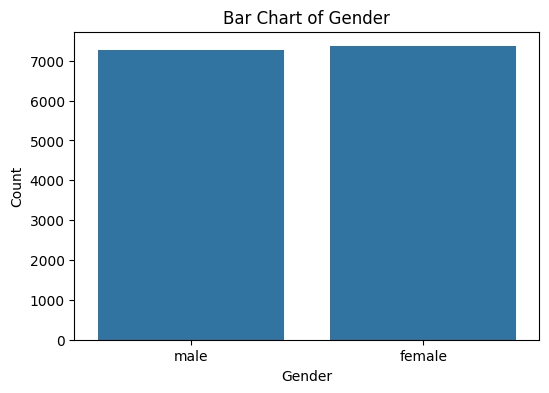

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def categorical_analysis(df, categorical_cols):
    """
    Performs frequency count and bar plot for categorical variables.
    """
    print("--- CATEGORICAL FEATURE ANALYSIS ---\n")
    
    for col in categorical_cols:
        print(f"Feature: {col}")
        
        # Frequency count
        counts = df[col].value_counts()
        print(counts)
        print("-" * 30)
        
        # Bar plot
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, data=df)
        plt.title(f"Bar Chart of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

# --- USAGE ---
categorical_analysis(df_clean, cat_cols)


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

def perform_one_hot_encoding(df):
    """
    Identifies categorical columns and performs One-Hot Encoding.
    Uses drop_first=True to avoid the Dummy Variable Trap (Multicollinearity).
    """
    print("--- 9. ONE-HOT ENCODING ---")
    
    # 1. Identify Categorical Columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Categorical columns found: {categorical_cols}")
    
    # 2. Apply One-Hot Encoding
    # drop_first=True removes the first category to prevent redundancy
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Convert booleans (True/False) to Integers (1/0) if pandas creates bools
    # This ensures everything is numeric for the model
    df_encoded = df_encoded.astype(float)
    
    print(f"Original shape: {df.shape}")
    print(f"New shape:      {df_encoded.shape}")
    print("✅ Encoding complete. Categorical text converted to numbers.")
    
    return df_encoded

# --- HOW TO RUN IT ---
df_final = perform_one_hot_encoding(df_scaled)


--- 9. ONE-HOT ENCODING ---
Categorical columns found: ['Gender']
Original shape: (14615, 8)
New shape:      (14615, 8)
✅ Encoding complete. Categorical text converted to numbers.


--- 10. VERIFYING ONE-HOT ENCODING ---
Binary Encoded Columns Found: ['Gender_male']

Analyzing: Gender_male
  - Count of 0 (females Group): 7358
  - Count of 1 (males Group):   7257


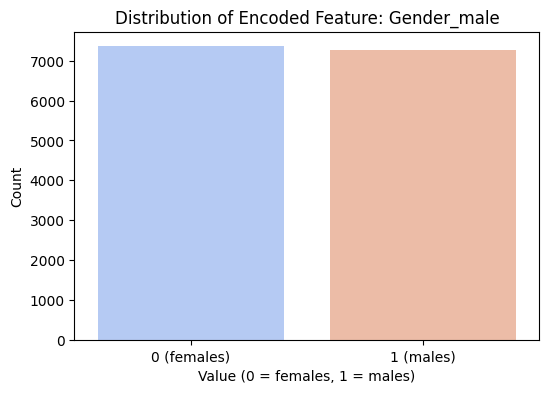

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

def verify_one_hot_encoding(df):
    """
    Automatically finds binary columns (0/1) created by encoding
    and plots their count to verify the split.
    """
    print("--- 10. VERIFYING ONE-HOT ENCODING ---")
    
    # 1. Find columns that only have 2 unique values (0 and 1)
    # This detects our new 'Gender_male' column automatically
    binary_cols = [col for col in df.columns if df[col].nunique() == 2]
    
    print(f"Binary Encoded Columns Found: {binary_cols}")
    
    if not binary_cols:
        print("❌ No binary columns found! Check your encoding step.")
        return

    # 2. Plot the new binary columns
    for col in binary_cols:
        print(f"\nAnalyzing: {col}")
        
        # Calculate counts
        counts = df[col].value_counts()
        count_0 = counts.get(0.0, 0)
        count_1 = counts.get(1.0, 0)
        
        print(f"  - Count of 0 (females Group): {count_0}")
        print(f"  - Count of 1 (males Group):   {count_1}")
        
        # Simple Bar Plot
        plt.figure(figsize=(6, 4))
        sns.countplot(x=df[col], hue=df[col], palette='coolwarm', legend=False)
        plt.title(f"Distribution of Encoded Feature: {col}")
        plt.xlabel("Value (0 = females, 1 = males)")
        plt.ylabel("Count")
        plt.xticks([0, 1], ['0 (females)', '1 (males)']) # Label the axis clearly
        plt.show()

# --- HOW TO RUN IT ---
# Pass your final encoded dataframe
verify_one_hot_encoding(df_final)

In [16]:
from sklearn.model_selection import train_test_split

def split_data(df, target_col):
    """
    1. Separates Features (X) and Target (y).
    2. Splits them into Training (80%) and Testing (20%) sets.
    3. Prints the shapes to verify.
    """
    print("--- 13. TRAIN-TEST SPLIT ---")
    
    # 1. Define X (Features) and y (Target)
    # Drop the target column to get features
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # 2. Perform the Split
    # test_size=0.2 means 20% of data goes to testing
    # random_state=42 ensures the split is reproducible (same every time)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. Print Results
    print(f"Total Rows: {len(df)}")
    print("-" * 30)
    print(f"Training Set (X_train): {X_train.shape} (80%)")
    print(f"Testing Set  (X_test):  {X_test.shape} (20%)")
    
    print("\n Data successfully split. Ready for Model Training.")
    
    return X_train, X_test, y_train, y_test

# --- HOW TO RUN IT ---
target_variable = 'Calories'
X_train, X_test, y_train, y_test = split_data(df_final, target_variable)

--- 13. TRAIN-TEST SPLIT ---
Total Rows: 14615
------------------------------
Training Set (X_train): (11692, 7) (80%)
Testing Set  (X_test):  (2923, 7) (20%)

 Data successfully split. Ready for Model Training.


In [17]:
# 1. Create a single dataframe for the Training Data
# We join X_train and y_train together
df_train = X_train.copy()
df_train[target_variable] = y_train  # Add 'Calories' back into the dataframe

# Check the shape to make sure it matches the 80% count
print(f"Training Data DataFrame Shape: {df_train.shape}")

Training Data DataFrame Shape: (11692, 8)


In [18]:
df_train.columns

Index(['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Gender_male', 'Calories'],
      dtype='object')

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import numpy as np

class DistributionAnalyzer:
    def __init__(self, df, column_name):
        """
        Initialize with the dataframe and the specific column to analyze.
        """
        self.data = df[column_name]
        self.col_name = column_name
        self.alpha = 0.05
        print(f"--- Initialized Analysis for: '{self.col_name}' ---")

    def plot_histogram_kde(self):
        """Plots Histogram with Kernel Density Estimate (Visual Shape)."""
        plt.figure(figsize=(10, 5))
        sns.histplot(self.data, kde=True, color='blue', bins=30)
        plt.title(f'Histogram + KDE: {self.col_name}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.show()

    def plot_boxplot(self):
        """Plots Boxplot to visualize Outliers."""
        plt.figure(figsize=(10, 3))
        sns.boxplot(x=self.data, color='orange')
        plt.title(f'Boxplot: {self.col_name}')
        plt.xlabel('Value')
        plt.show()

    def plot_qq(self):
        """Plots Q-Q Plot to check alignment with theoretical Normal distribution."""
        plt.figure(figsize=(8, 6))
        stats.probplot(self.data, dist="norm", plot=plt)
        plt.title(f'Q-Q Plot: {self.col_name}')
        plt.show()

    def plot_test_results(self):
        """
        Visualizes the Anderson-Darling Test Result.
        Plots the Test Statistic against the Critical Value (at 5%).
        """
        result = stats.anderson(self.data, dist='norm')
        
        # Get the critical value for 5% significance
        try:
            idx = list(result.significance_level).index(5.0)
            crit_val = result.critical_values[idx]
        except ValueError:
            print("Could not find 5% critical value for plotting.")
            return

        stat_val = result.statistic
        
        # Prepare data for plotting
        labels = ['Test Statistic', 'Critical Value (5%)']
        values = [stat_val, crit_val]
        colors = ['red' if stat_val > crit_val else 'green', 'gray']
        
        plt.figure(figsize=(8, 4))
        bars = plt.barh(labels, values, color=colors)
        
        # Add value labels on the bars
        for bar in bars:
            plt.text(bar.get_width() + (max(values)*0.01), 
                     bar.get_y() + bar.get_height()/2, 
                     f'{bar.get_width():.4f}', 
                     va='center', fontsize=10, weight='bold')

        plt.title(f'Normality Test Visualization (Anderson-Darling)\n{self.col_name}')
        plt.xlim(0, max(values) * 1.2) # Add some breathing room
        plt.xlabel('Value')
        
        # Interpretation Note
        if stat_val > crit_val:
            plt.figtext(0.5, -0.05, "Result: REJECT Normality (Statistic > Critical)", ha="center", color="red", weight="bold")
        else:
            plt.figtext(0.5, -0.05, "Result: ACCEPT Normality (Statistic < Critical)", ha="center", color="green", weight="bold")
            
        plt.tight_layout()
        plt.show()

    def test_anderson(self):
        """Performs Anderson-Darling Test (Primary Test)."""
        result = stats.anderson(self.data, dist='norm')
        print(f"\n[Anderson-Darling Test]")
        print(f"Statistic: {result.statistic:.4f}")
        try:
            idx = list(result.significance_level).index(5.0)
            crit_val = result.critical_values[idx]
            print(f"Critical Value (at 5%): {crit_val:.4f}")
            if result.statistic < crit_val:
                print("Result: Data looks Normal (Fail to reject H0)")
            else:
                print("Result: Data is NOT Normal (Reject H0)")
        except ValueError:
            print("Could not find 5% critical value.")

    def test_dagostino(self):
        """Performs D’Agostino–Pearson Test (Confirmation)."""
        stat, p = stats.normaltest(self.data)
        print(f"\n[D’Agostino–Pearson Test]")
        print(f"Statistic: {stat:.4f}, p-value: {p:.4g}")
        if p > self.alpha:
            print("Result: Data looks Normal (Fail to reject H0)")
        else:
            print("Result: Data is NOT Normal (Reject H0)")

    # def test_shapiro(self):
    #     """Performs Shapiro-Wilk Test (Sensitivity Check)."""
    #     stat, p = stats.shapiro(self.data)
    #     print(f"\n[Shapiro-Wilk Test]")
    #     print(f"Statistic: {stat:.4f}, p-value: {p:.4g}")
    #     if len(self.data) > 5000:
    #         print("⚠️ Note: Sample size > 5000. This test is highly sensitive.")
    #     if p > self.alpha:
    #         print("Result: Data looks Normal (Fail to reject H0)")
    #     else:
    #         print("Result: Data is NOT Normal (Reject H0)")

    def run_full_analysis(self):
        """
        Runs the complete suite of visual and statistical checks.
        """
        # 1. Visual Distribution
        self.plot_histogram_kde()
        
        # 2. Outliers
        self.plot_boxplot()
        
        # 3. Normality Visual Check
        self.plot_qq()
        
        # 4. Normality Statistical Test Visualization (New!)
        self.plot_test_results()
        
        # 5. Text-based Test Outputs
        print("-" * 50)
        print("STATISTICAL TEST DETAILS:")
        self.test_anderson()
        self.test_dagostino()
        # self.test_shapiro()
        print("-" * 50)

## Feature 1: Age

### 🔹 Visual Inspection

**Histogram + KDE** The histogram and kernel density estimate show a **unimodal but asymmetric distribution**.  
The density curve rises to a peak and trails off to the right, indicating **positive skewness**. It does not form a perfectly symmetric Gaussian bell curve.

**Boxplot** The boxplot reveals **asymmetry in the data spread**, with the median slightly off-center within the interquartile range.  
The whiskers extend further on the right side, confirming **positive skewness**.  
No extreme outliers dominate the distribution.

**Q–Q Plot** The Q–Q plot shows **deviations from the theoretical normal line**, particularly at the tails (S-shape).  
This indicates that the *Age* feature has different kurtosis (tail weight) than a standard normal distribution and **does not satisfy the strict normality assumption**.

---

### 🔹 Distribution Type

Based on visual analysis:
- The *Age* feature is **Non-Gaussian** (statistically).
- The distribution is **Positively Skewed (Right-Skewed)**.
- **NOT Exponential** (it rises and falls, unlike an exponential decay).
- This behavior is common in biological/demographic data (natural variance).

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**
- **Test Statistic** ($283.23$) $\gg$ **Critical Value** ($0.787$)
- The test result falls deep into the **Rejection Region**.

**Hypotheses:**
- **$H_0$ (Null Hypothesis):** The *Age* feature follows a Normal distribution.
- **$H_1$ (Alternative Hypothesis):** The *Age* feature does **not** follow a Normal distribution.

**Decision:** Reject $H_0$ $\rightarrow$ *Age is not statistically normally distributed.*

---

#### **D’Agostino–Pearson Test (Confirmation Test)**
- **p-value** $\approx 0$ (< 0.05)
- Strong evidence against normality.

**Decision:** Reject $H_0$.

---

### 🔹 Final Conclusion for *Age*

Both **visual methods** and **statistical tests** indicate that the *Age* feature is **not normally distributed** due to skewness and sample size sensitivity.

**Implication:** - Normality assumptions are formally violated.  
- However, the shape is not "pathological" (it is still roughly bell-shaped), so linear models may still perform reasonably well without transformation.

--- Initialized Analysis for: 'Age' ---


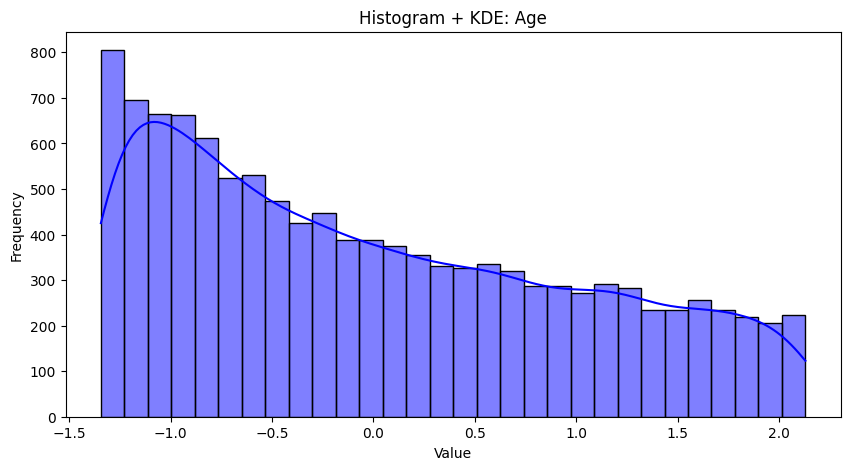

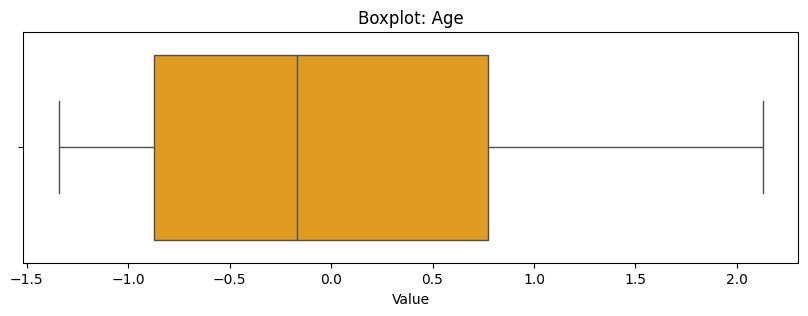

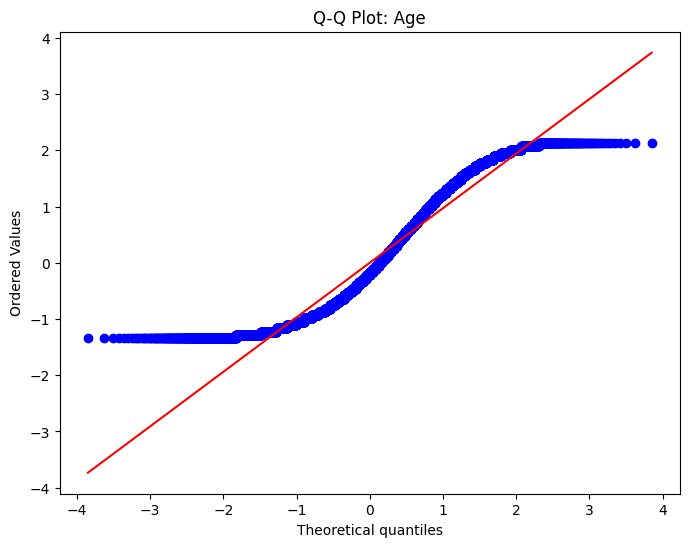

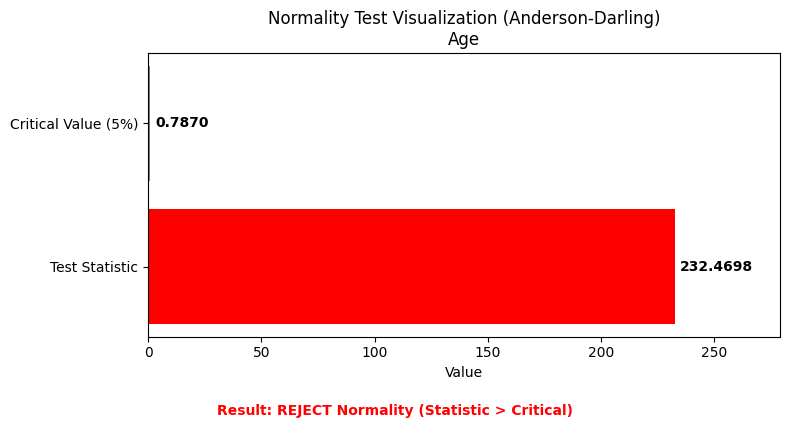

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 232.4698
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 2656.4073, p-value: 0
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [20]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Age')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 2: Gender_male (Binary Encoded Feature)

### 1 Visual Inspection (Histogram & KDE)

- The histogram shows **two discrete spikes** at values 0 and 1.
- **Note on KDE:** The continuous curve is **misleading** here because it tries to smooth discrete binary data. It should be ignored in favor of the bars.

**Distribution Type:**
- Not Gaussian, Exponential, or Uniform.
- **Bernoulli / Binary Distribution** (Success/Failure).

---

### 2. Boxplot

- The boxplot spans from 0 to 1.
- No meaningful outliers exist.
- Boxplot is **not informative for binary variables**.

---

### 3. Q–Q Plot

- Points form two horizontal bands.
- Strong deviation from the normal reference line.

**Interpretation:**
- Binary variables cannot satisfy normality assumptions.

---

### 4. Statistical Normality Tests

#### Anderson–Darling Test

- Test Statistic ≫ Critical Value
-  Reject H₀

#### D’Agostino–Pearson Test

- p-value ≈ 0
-  Reject H₀

**Note:**  
Normality tests are **not theoretically applicable** to binary variables, but rejection is expected.

---

###  Final Conclusion for Gender_male

- **Gender_male** follows a **Bernoulli (binary categorical) distribution**.
- Normality assumptions are **invalid by definition**.
- Statistical normality tests correctly reject normality.
- This feature should be treated as **categorical**, not continuous.

---

--- Initialized Analysis for: 'Gender_male' ---


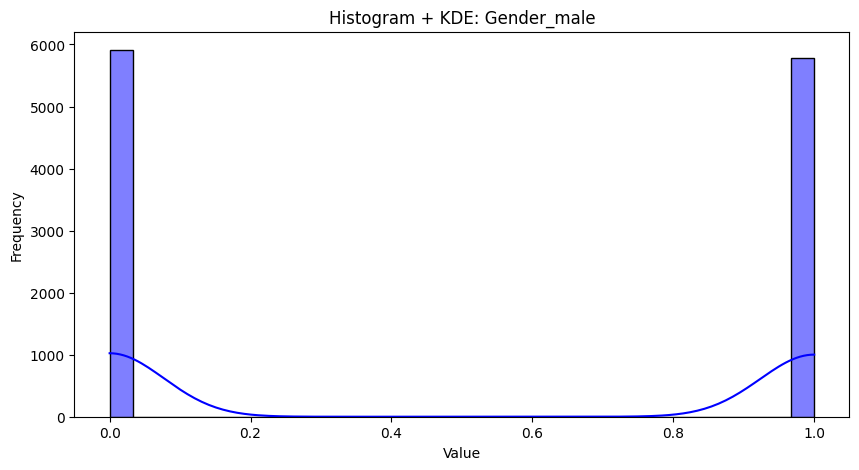

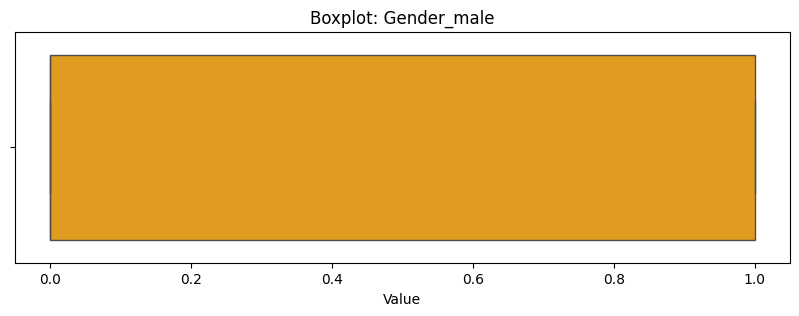

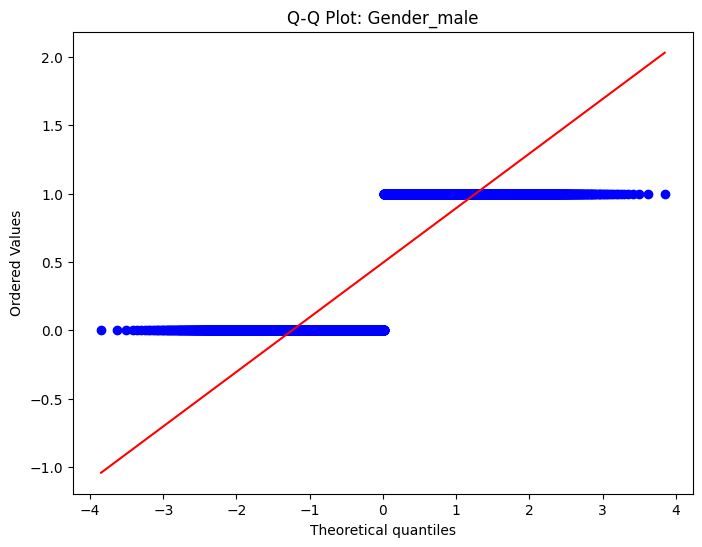

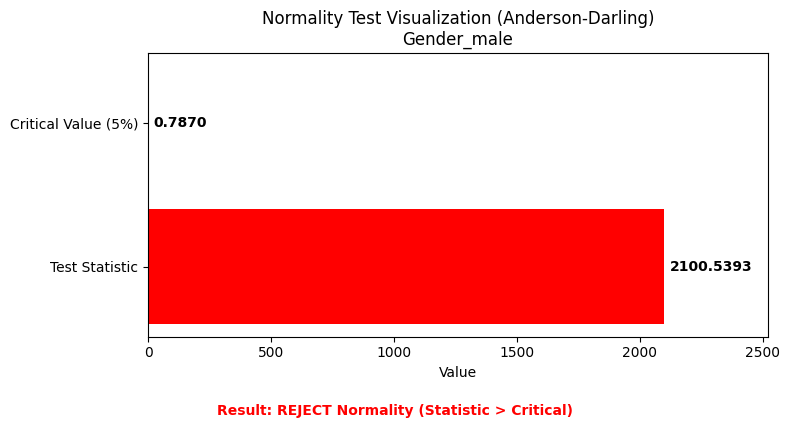

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 2100.5393
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 40171.9044, p-value: 0
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [21]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Gender_male')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 3: Height

---

### 🔹 Visual Inspection

**Histogram + KDE**  
- The histogram shows a **symmetric, bell-shaped distribution** centered around the mean.  
- The KDE curve closely follows a **Gaussian (normal) shape**, indicating approximate normality.  
- Minor deviations appear at the tails, which is common in large real-world datasets.

**Boxplot**  
- The boxplot is **approximately symmetric** with the median near the center of the interquartile range.  
- No extreme outliers are present.  
- This supports the assumption of a **well-behaved continuous distribution**.

**Q–Q Plot**  
- The Q–Q plot shows most points lying **close to the theoretical normal line**.  
- Slight deviations occur at the extreme tails, suggesting **mild tail departures** from perfect normality.

---

### 🔹 Distribution Type

Based on visual analysis and concepts studied during the semester:

- The *Height* feature is **approximately Gaussian (Normal)**  
- Symmetric distribution  
- Continuous random variable  
- Minor tail deviations are expected in large samples due to natural variability  

This aligns with theoretical expectations from **biostatistics and probability theory**, where physical measurements (e.g., height, weight) often follow a **normal distribution**.

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)  
- The test rejects normality

**Hypotheses:**
- **H₀ (Null Hypothesis):** Height follows a normal distribution  
- **H₁ (Alternative Hypothesis):** Height does not follow a normal distribution  

**Decision:**  
Reject H₀

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≪ 0.05  
- Reject H₀

---

### 🔹 Interpretation of the Test Results

Although both statistical tests reject strict normality:

- The dataset contains a **large sample size**, making normality tests **highly sensitive**  
- Even small, practically insignificant deviations lead to rejection  
- Visual diagnostics indicate **near-normal behavior**

This outcome is consistent with the **Central Limit Theorem** and known behavior of medical data.

---

###  Final Conclusion for *Height*

- *Height* follows an **approximately normal (Gaussian) distribution**  
- Visual diagnostics strongly support normality  
- Statistical rejection is driven by **large sample size**, not severe deviation  
- The feature is suitable for:
  - Parametric statistical methods  
  - Standardization (e.g., z-score)  
  - Models assuming approximate normality  

**No transformation is required** unless demanded by a specific downstream model.

---


--- Initialized Analysis for: 'Height' ---


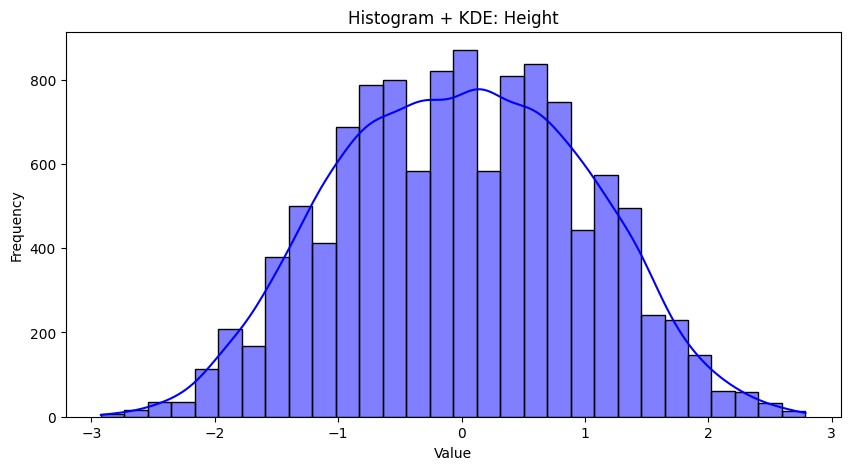

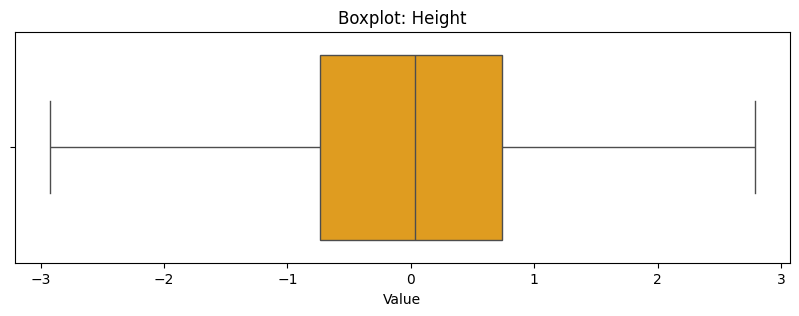

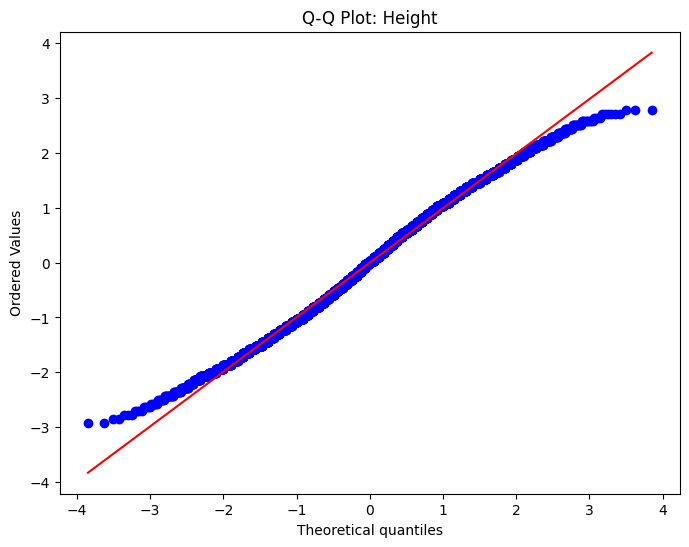

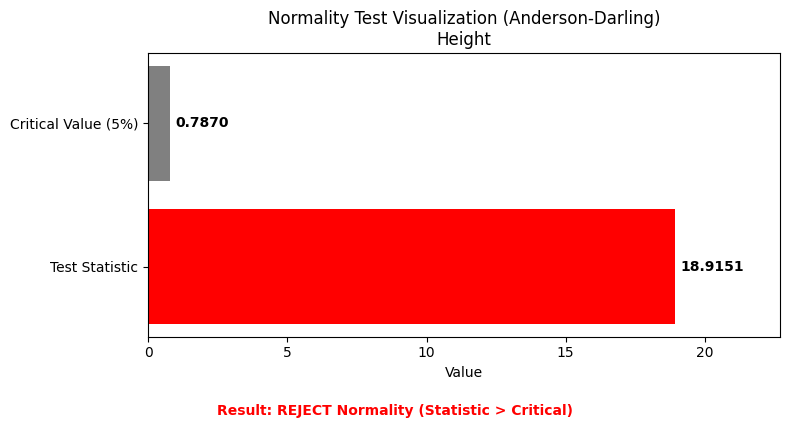

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 18.9151
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 308.8726, p-value: 8.495e-68
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [22]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Height')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 4: Weight

### 🔹 Visual Inspection

**Histogram + KDE**  
The histogram shows a **continuous distribution** with a clear central peak, but it is **not perfectly symmetric**.  
The KDE curve indicates **asymmetry with heavier tails**, suggesting deviation from a pure Gaussian shape.  
The distribution appears slightly **right-skewed**, which is common in medical measurements related to body mass.

**Boxplot**  
The boxplot shows a **moderate spread** with the median slightly off-center.  
A small number of **upper-end outliers** are present, indicating individuals with higher-than-average weight values.  
Overall, the distribution is not symmetric.

**Q–Q Plot**  
The Q–Q plot follows the normal reference line in the **central region**, but shows **clear deviations at both tails**, especially the upper tail.  
This indicates departure from normality despite approximate normal behavior in the center.

---

### 🔹 Distribution Type

Based on visual analysis and concepts studied during the semester:

- The *Weight* feature is **continuous**
- It is **not perfectly Gaussian**
- Exhibits **slight right skewness**
- Shows **heavy tails (leptokurtic behavior)**

**Closest description:**  
- **Approximately normal in the center**, but **non-Gaussian overall**
- Common for **biomedical and anthropometric data**

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)
- Strong evidence against normality

**Hypotheses:**
- **H₀ (Null Hypothesis):** Weight follows a normal distribution  
- **H₁ (Alternative Hypothesis):** Weight does not follow a normal distribution  

**Decision:**  
 Reject H₀ → *Weight is not normally distributed*

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≪ 0.05
- Strong rejection of normality

**Decision:**  
 Reject H₀

---

### 🔹 Final Conclusion for *Weight*

Both **visual diagnostics** (Histogram, KDE, Boxplot, Q–Q plot) and **statistical tests** consistently indicate that the *Weight* feature **does not strictly follow a normal distribution**.

**Key interpretation (aligned with course material):**
- Approximate normality in the center does **not guarantee full normality**
- Large sample size makes normality tests very sensitive
- Deviations at the tails are sufficient to reject H₀

**Implications:**
- Normality assumption is **violated**
- This is **expected in medical datasets**
- Transformations (e.g., log or Box–Cox) may be considered **only if required** by downstream statistical models
- Non-parametric methods are appropriate alternatives

---


--- Initialized Analysis for: 'Weight' ---


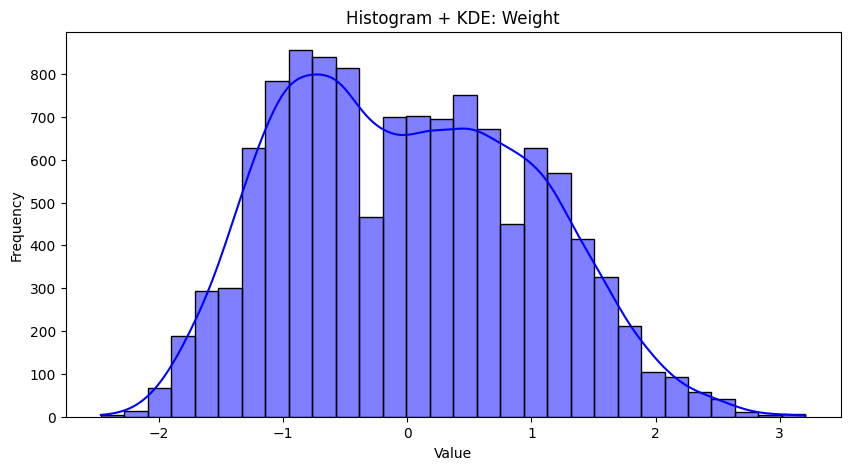

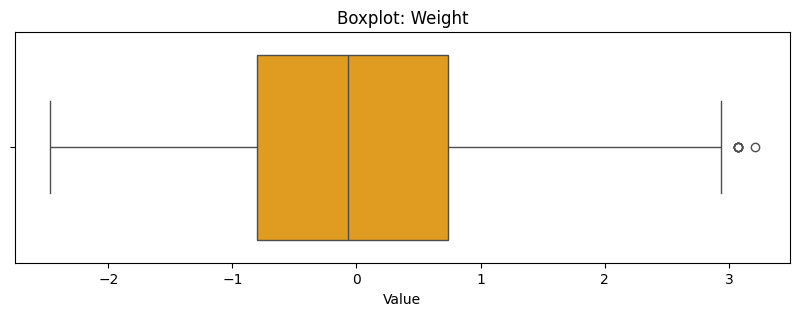

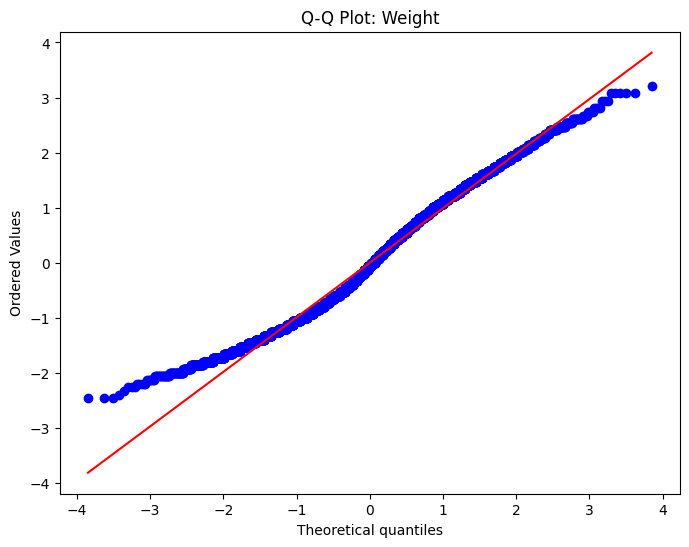

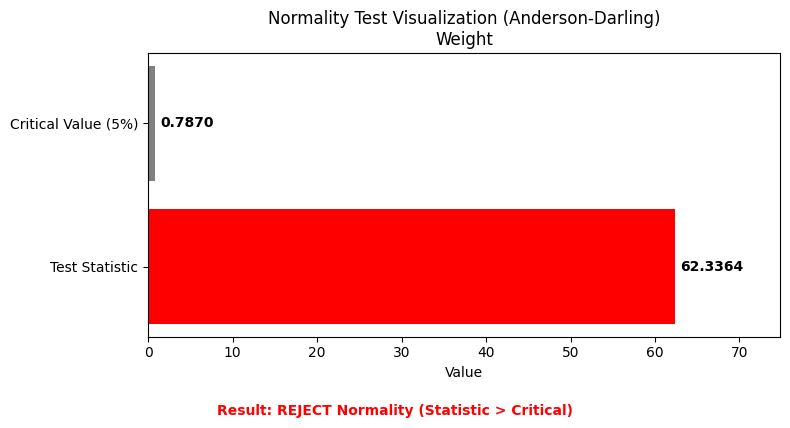

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 62.3364
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 777.6447, p-value: 1.37e-169
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [23]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Weight')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 5: Duration

### 🔹 Visual Inspection

**Histogram + KDE**  
The histogram shows a **fairly flat and spread-out distribution** across the range of values, with no single dominant peak.  
The KDE curve appears **almost constant over a wide interval**, indicating the absence of a bell-shaped structure.  
This suggests that the *Duration* feature **does not follow a Gaussian (normal) distribution**.

**Boxplot**  
The boxplot shows a **wide interquartile range** with the median approximately centered.  
There are **no dominant extreme outliers**, but the spread is large, which is consistent with a broadly distributed variable rather than a concentrated one.

**Q–Q Plot**  
The Q–Q plot exhibits **systematic deviations from the straight reference line**, particularly at both tails.  
This clear curvature indicates a **violation of the normality assumption**.

---

### 🔹 Distribution Type

Based on the visual analysis and concepts covered during the semester:

- The *Duration* feature is **non-Gaussian**
- The distribution is **approximately uniform-like** over a bounded interval
- It is **not Normal (Gaussian)**
- It is **not Exponential** (no strong right skew or rapid decay)
- Closest resemblance: **Uniform distribution**

Such behavior is common for **time-related variables** where values are spread relatively evenly within a fixed range.

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)
- Strong evidence against normality

**Hypotheses:**
- **H₀ (Null Hypothesis):** The *Duration* feature follows a normal distribution  
- **H₁ (Alternative Hypothesis):** The *Duration* feature does not follow a normal distribution  

**Decision:**  
 Reject H₀ → *Duration is not normally distributed*

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≈ 0
- Strong evidence against normality

**Decision:**  
 Reject H₀

---

### Conclusion for *Duration*

Both **visual diagnostics** (Histogram, KDE, Boxplot, Q–Q plot) and **statistical tests** consistently show that the *Duration* feature **does not satisfy the normality assumption**.

**Implications:**
- Normality-based statistical methods are **not appropriate** for this feature
- No transformation is strictly required unless imposed by a specific model
- The feature should be treated as a **continuous, bounded, non-Gaussian variable**, consistent with concepts of **uniform distributions** studied during the semester


--- Initialized Analysis for: 'Duration' ---


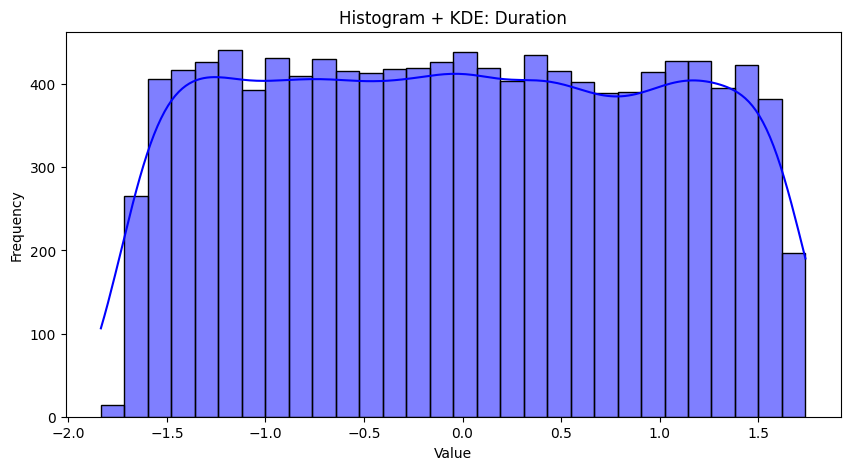

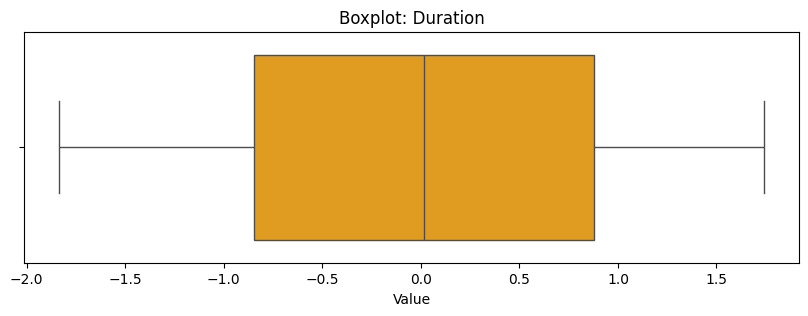

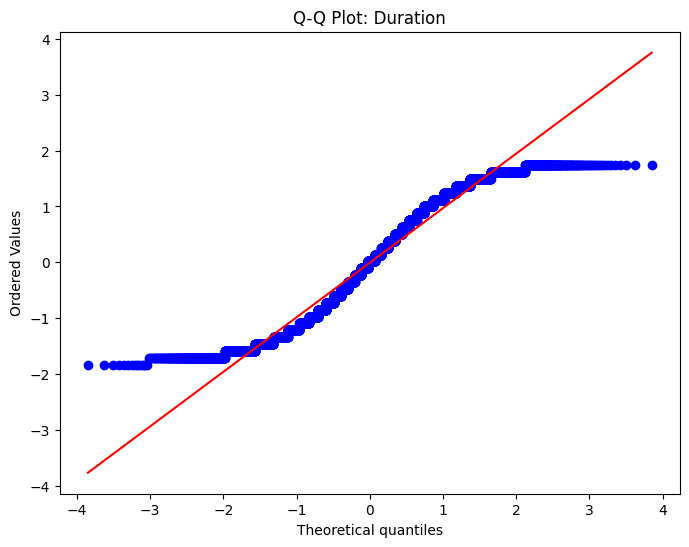

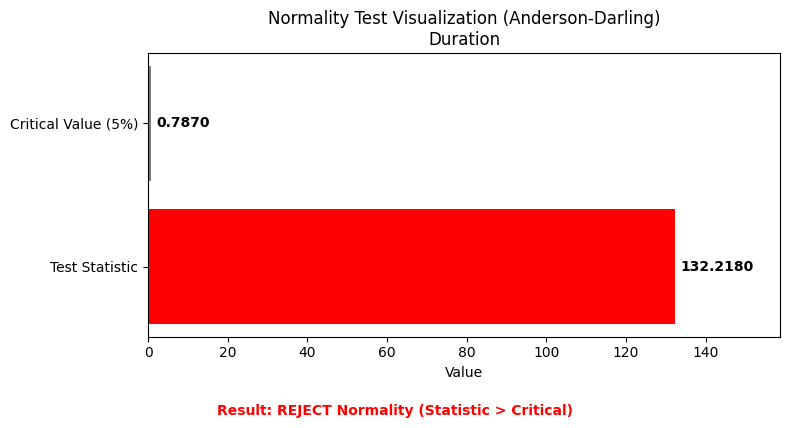

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 132.2180
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 9055.2913, p-value: 0
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [24]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Duration')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 6: Heart_Rate

---

### 🔹 Visual Inspection

**Histogram + KDE**

- The histogram shows a **symmetric, bell-shaped distribution** centered around the mean.
- The KDE curve closely resembles a **normal (Gaussian) distribution**.
- Minor deviations are observed at the extreme tails.

**Boxplot**

- The median is approximately centered within the interquartile range.
- The spread appears symmetric.
- A small number of mild outliers exist, which is common in physiological measurements.

**Q–Q Plot**

- Most points lie close to the theoretical normal line.
- Slight deviations appear at the lower and upper tails.
- Overall, the plot suggests **approximate normality** with mild tail departures.

---

### 🔹 Distribution Type

Based on visual analysis:

- Approximately **Gaussian (Normal)**
- Symmetric distribution
- Slight tail deviations
- Common behavior in **physiological and biomedical measurements** such as heart rate

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)
- The test rejects normality

**Hypotheses:**

- **H₀ (Null Hypothesis):** The *Heart_Rate* feature follows a normal distribution  
- **H₁ (Alternative Hypothesis):** The *Heart_Rate* feature does not follow a normal distribution  

**Decision:**  
Reject H₀

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≪ 0.05
- Strong evidence against strict normality

**Decision:**  
Reject H₀

---

### 🔹 Interpretation of Results

- Despite **statistical rejection of normality**, visual methods indicate that *Heart_Rate* is **approximately normally distributed**.
- With a **large sample size**, normality tests become **highly sensitive**, rejecting even small deviations.
- According to the **Central Limit Theorem**, such deviations are acceptable in large biomedical datasets.

---

### Conclusion for *Heart_Rate*

- *Heart_Rate* follows an **approximately Gaussian distribution**.
- Minor deviations from normality exist at the tails.
- Statistical tests reject strict normality due to large sample size.
- The feature can be treated as **continuous and approximately normal** for:
  - Parametric statistical analysis
  - Machine learning models
  - Biomedical interpretation

**No transformation is required unless a model explicitly assumes strict normality.**

---


--- Initialized Analysis for: 'Heart_Rate' ---


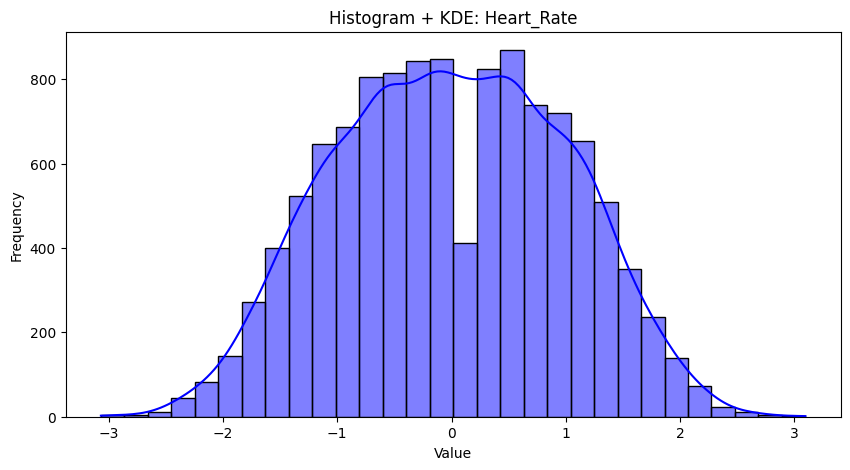

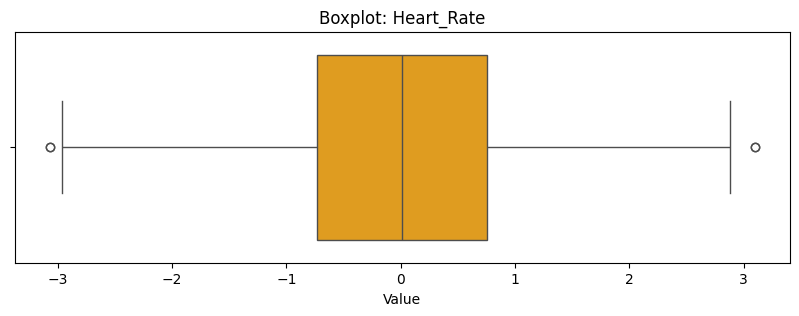

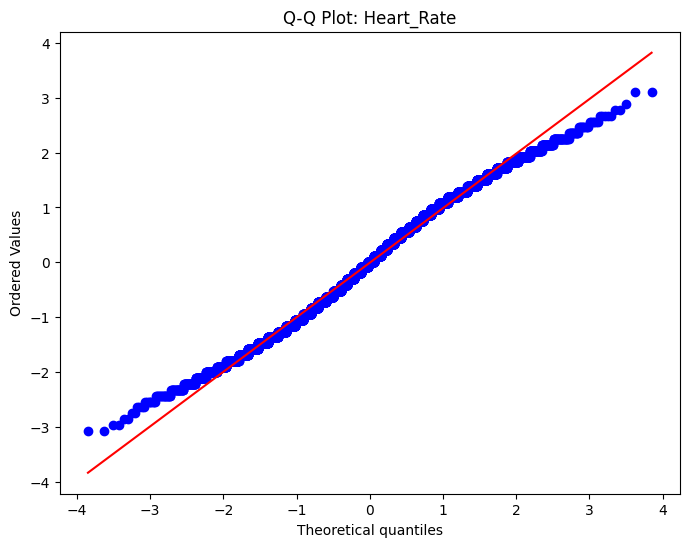

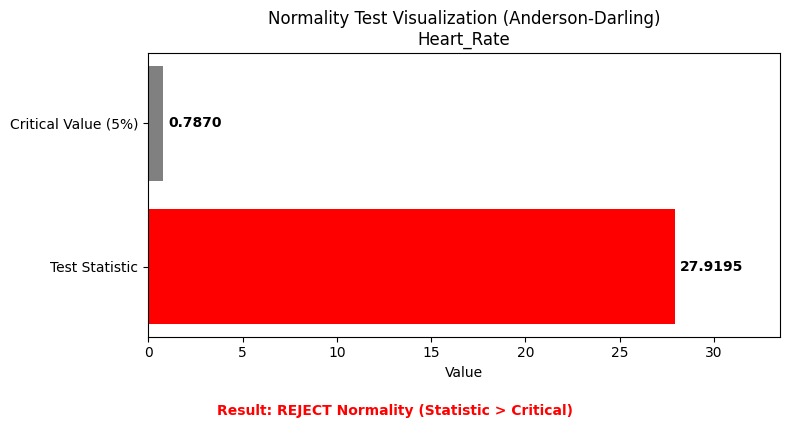

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 27.9195
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 446.8382, p-value: 9.34e-98
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [25]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train,'Heart_Rate')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## Feature 7: Body_Temp

---

### 🔹 Visual Inspection

**Histogram + KDE**

- The histogram shows a **skewed and asymmetric distribution**.
- The KDE curve does **not resemble a bell-shaped Gaussian form**.
- A noticeable tail is present, indicating **departure from symmetry**.

**Boxplot**

- The median is **not centered** within the interquartile range.
- The spread is asymmetric.
- Several **outliers** are observed, particularly on the lower side, which is common in clinical temperature measurements.

**Q–Q Plot**

- Significant deviations from the theoretical normal line are visible.
- Strong curvature appears at both tails.
- The plot clearly indicates **non-normal behavior**.

---

### 🔹 Distribution Type

Based on visual analysis:

- **Non-Gaussian (Non-Normal)**
- Skewed distribution
- Presence of outliers
- Typical of **physiological and medical data**, especially body temperature variations

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)
- The test strongly rejects normality

**Hypotheses:**

- **H₀ (Null Hypothesis):** The *Body_Temp* feature follows a normal distribution  
- **H₁ (Alternative Hypothesis):** The *Body_Temp* feature does not follow a normal distribution  

**Decision:**  
Reject H₀

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≪ 0.05
- Indicates significant skewness and kurtosis

**Decision:**  
Reject H₀

---

### 🔹 Interpretation of Results

- Both **visual inspection** and **statistical tests** consistently indicate that *Body_Temp* is **not normally distributed**.
- Unlike *Heart_Rate*, the deviations from normality are **substantial and not only due to large sample size**.
- The presence of skewness and outliers reflects **real clinical variability** rather than noise.

---

### Conclusion for *Body_Temp*

- *Body_Temp* does **not follow a Gaussian distribution**.
- The distribution is skewed with clinically meaningful outliers.
- Statistical tests and visual methods agree on non-normality.
- The feature should be treated as **non-parametric** for:
  - Statistical hypothesis testing
  - Clinical interpretation
  - Robust modeling

**Data transformation (e.g., Box–Cox or Yeo–Johnson) or non-parametric methods are recommended if normality is required.**

---


--- Initialized Analysis for: 'Body_Temp' ---


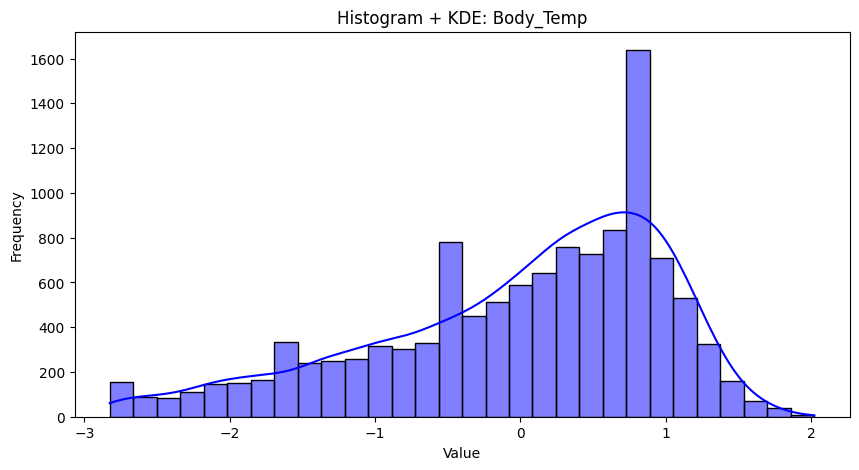

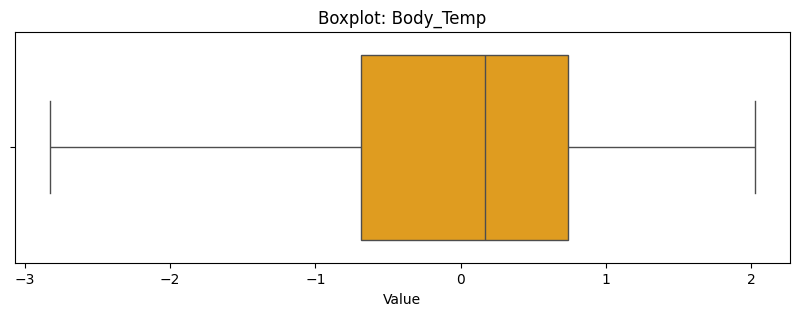

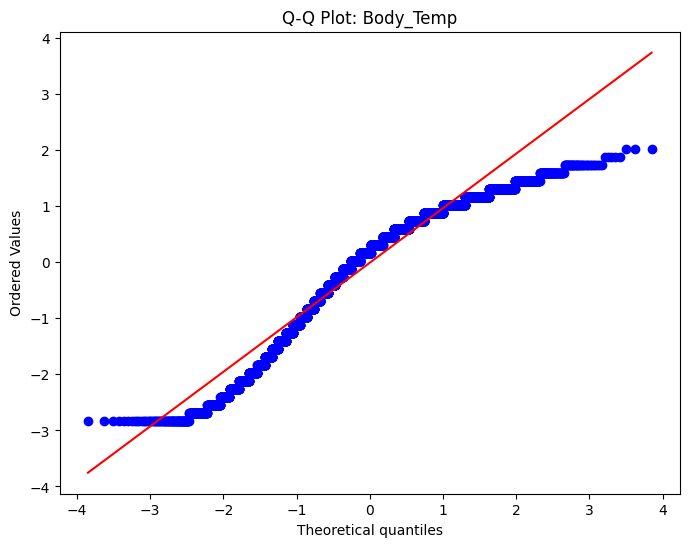

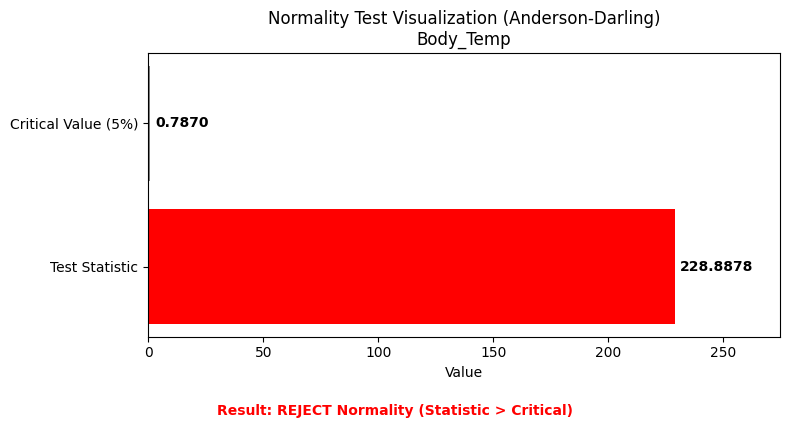

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 228.8878
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 964.0400, p-value: 4.585e-210
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [26]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Body_Temp')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

##  Target Variable: Calories

---

### 🔹 Visual Inspection

**Histogram + KDE**

- The histogram shows a **strong right-skewed distribution**.
- Most observations are concentrated at **lower calorie values**, with a **long tail extending toward higher values**.
- The KDE curve confirms **asymmetry** and a clear deviation from a bell-shaped (Gaussian) distribution.

**Boxplot**

- The median is shifted toward the lower end of the distribution.
- A **long upper whisker** and several **high-value outliers** are observed.
- This pattern indicates **positive skewness**, which is typical for caloric expenditure data.

**Q–Q Plot**

- Points show **strong deviation** from the theoretical normal line.
- Pronounced curvature appears, especially in the **upper tail**.
- Confirms that *Calories* **does not satisfy the normality assumption**.

---

### 🔹 Distribution Type

Based on visual analysis:

- **Non-Gaussian**
- **Right-skewed (positively skewed)**
- Heavy upper tail
- Closest to:
  - **Exponential-type distributions**

This behavior is **expected for a regression target**, as caloric expenditure is naturally bounded below and unbounded above.

---

### 🔹 Statistical Normality Tests

#### **Anderson–Darling Test (Primary Test)**

- Test Statistic ≫ Critical Value (5%)
- Strong rejection of normality

**Hypotheses:**

- **H₀ (Null Hypothesis):** The *Calories* target follows a normal distribution  
- **H₁ (Alternative Hypothesis):** The *Calories* target does not follow a normal distribution  

**Decision:**  
Reject H₀

---

#### **D’Agostino–Pearson Test (Confirmation Test)**

- p-value ≪ 0.05
- Extremely strong evidence against normality

**Decision:**  
Reject H₀

---

### 🔹 Interpretation for a Regression Target

- **Normality of the target variable is not required** for most machine learning models.
- Tree-based models and neural networks naturally handle **non-normal and skewed targets**.
- For linear or parametric models, skewness may affect:
  - Error symmetry
  - Variance stability
  - Model interpretability

The observed skewness reflects **real physiological variability**, not data quality issues.

---

###  Final Conclusion for *Calories*

- *Calories* is **clearly non-normally distributed**.
- The distribution is **right-skewed with high-end outliers**.
- Statistical tests correctly reject normality.
- This distribution is **expected and appropriate** for a metabolic regression target.

**Practical Implications:**

- Treat *Calories* as a **continuous regression target**.

---


--- Initialized Analysis for: 'Calories' ---


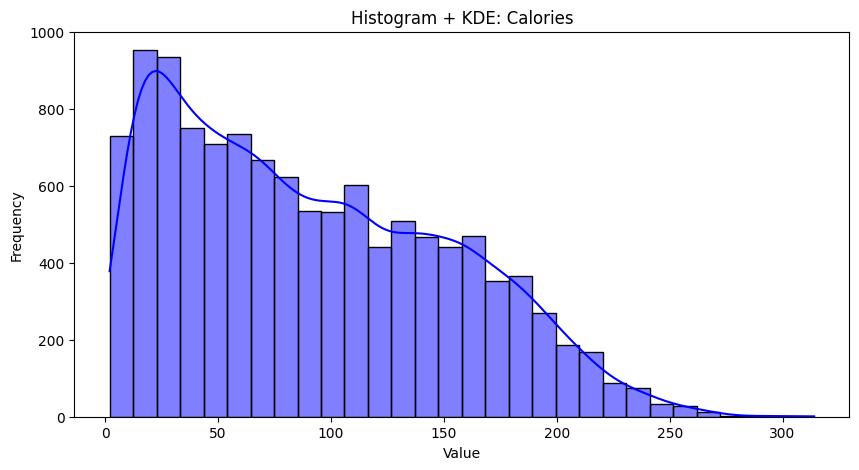

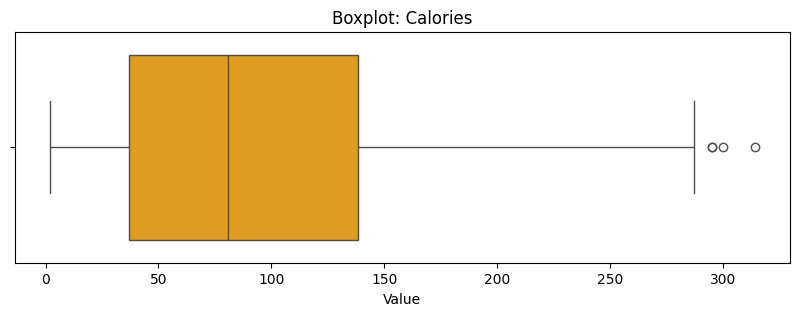

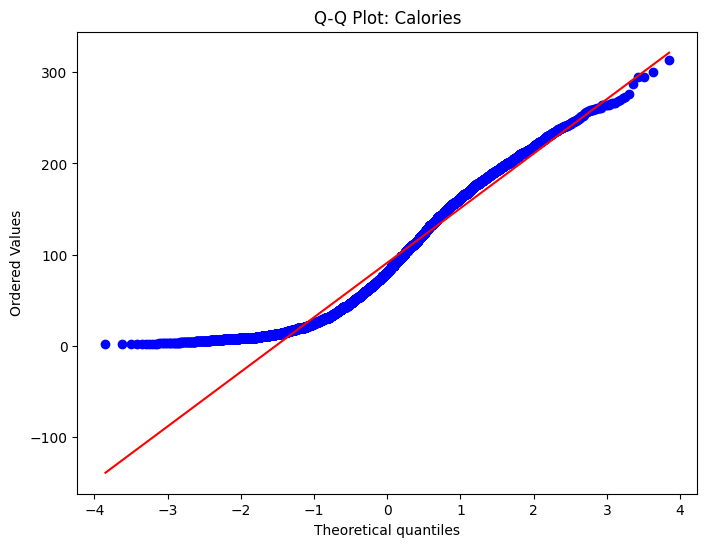

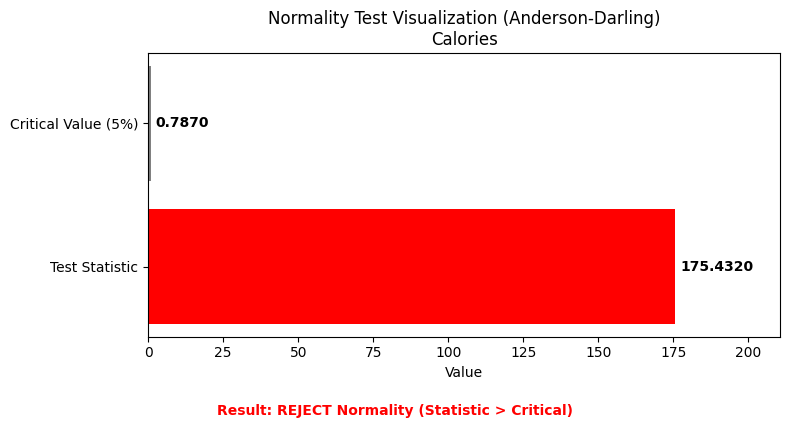

--------------------------------------------------
STATISTICAL TEST DETAILS:

[Anderson-Darling Test]
Statistic: 175.4320
Critical Value (at 5%): 0.7870
Result: Data is NOT Normal (Reject H0)

[D’Agostino–Pearson Test]
Statistic: 1098.1819, p-value: 3.411e-239
Result: Data is NOT Normal (Reject H0)
--------------------------------------------------


In [27]:
# Create the analyzer
analyzer = DistributionAnalyzer(df_train, 'Calories')

# Run everything (including the new test plot)
analyzer.run_full_analysis()

## 🔹 Correlation Analysis with Target Variable (*Calories*)

---

###  Objective

To quantify the strength and direction of the relationship between the response variable (**Calories**) and each predictor using:

- **Pearson Correlation** (linear relationships)
- **Spearman Correlation** (monotonic relationships, robust to non-normality)

This dual approach is appropriate given the **non-normal distributions** observed in previous EDA.

---

### 🔹 Pearson Correlation Results (Linear Relationship)

| Feature       | Correlation with Calories |
|--------------|---------------------------|
| **Duration** | **0.95** |
| **Heart_Rate** | **0.89** |
| **Body_Temp** | **0.84** |
| Age | 0.15 |
| Weight | 0.03 |
| Height | 0.02 |

**Interpretation:**

- **Duration** shows a **very strong positive linear correlation**, making it the most influential predictor.
- **Heart_Rate** and **Body_Temp** also exhibit **strong positive linear relationships** with Calories.
- **Age**, **Weight**, and **Height** have **weak or negligible linear correlation**, suggesting limited predictive power in a linear context.

---

### 🔹 Spearman Correlation Results (Monotonic Relationship)

| Feature       | Correlation with Calories |
|--------------|---------------------------|
| **Duration** | **0.97** |
| **Body_Temp** | **0.91** |
| **Heart_Rate** | **0.91** |
| Age | 0.13 |
| Weight | 0.01 |
| Height | 0.00 |

**Interpretation:**

- The **ranking-based (Spearman)** correlations reinforce the Pearson findings.
- Strong monotonic relationships exist between **Calories** and:
  - **Duration**
  - **Heart_Rate**
  - **Body_Temp**
- Near-zero values for **Height** and **Weight** confirm their minimal contribution.
- The consistency between Pearson and Spearman results indicates **stable, reliable associations**.

---

### 🔹 Heatmap Interpretation

- The correlation heatmap visually confirms:
  - Strong associations between **Calories** and **Duration, Heart_Rate, Body_Temp**
  - Weak relationships with **Age, Height, Weight**
- High correlation among some predictors (e.g., **Duration–Heart_Rate**) suggests potential **multicollinearity**, which should be considered during modeling.

---

###  Conclusions for Target (*Calories*)

- **Primary predictors of Calories:**
  - **Duration**
  - **Heart_Rate**
  - **Body_Temp**

- **Secondary / weak predictors:**
  - Age
  - Weight
  - Height

- The strong agreement between Pearson and Spearman correlations:
  - Validates robustness of results
  - Supports inclusion of the top predictors in regression or ML models

- These findings are **physiologically intuitive** and align with **exercise and metabolic principles**.

---

### 🔍 Modeling Implications

- Linear models (e.g., Linear Regression) are appropriate due to strong linear signals.
- Tree-based and ML models may further exploit nonlinear interactions.
- Multicollinearity diagnostics (e.g., **VIF**) are recommended before final model selection.

---


--- CORRELATION ANALYSIS (Target: Calories) ---

🔹 Pearson Correlation with Calories:
Duration      0.954281
Heart_Rate    0.894082
Body_Temp     0.837457
Age           0.153417
Weight        0.033272
Height        0.015952
Name: Calories, dtype: float64

🔹 Spearman Correlation with Calories:
Duration      0.973915
Body_Temp     0.913876
Heart_Rate    0.912280
Age           0.131995
Weight        0.009953
Height       -0.001749
Name: Calories, dtype: float64


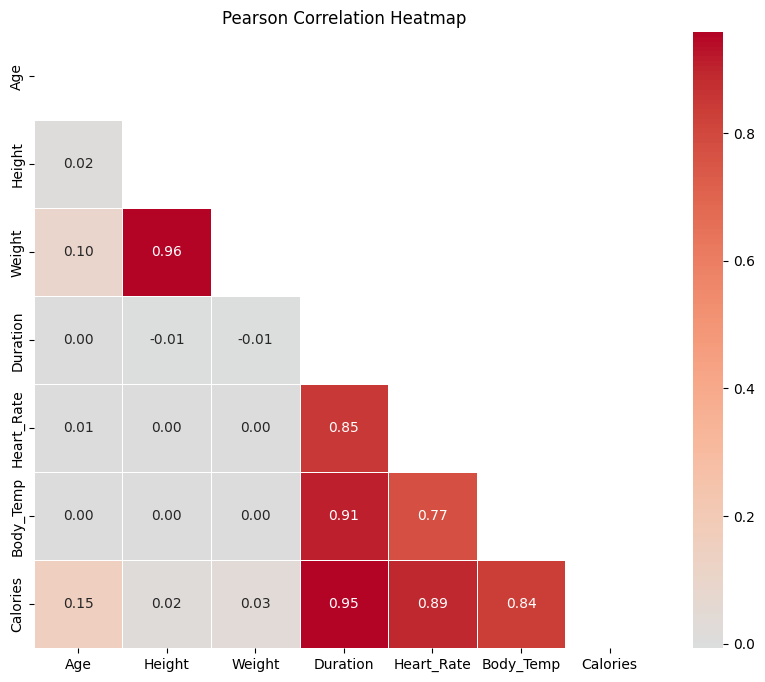

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_correlations(df, target_col, predictors):
    """
    Computes Pearson and Spearman correlations between target and predictors.
    Displays sorted tables and heatmaps.
    """
    print(f"--- CORRELATION ANALYSIS (Target: {target_col}) ---")

    cols_to_analyze = predictors + [target_col]

    # Pearson correlation
    pearson_corr = df[cols_to_analyze].corr(method='pearson')
    pearson_target = pearson_corr[target_col].drop(target_col).sort_values(ascending=False)

    print("\n🔹 Pearson Correlation with Calories:")
    print(pearson_target)

    # Spearman correlation
    spearman_corr = df[cols_to_analyze].corr(method='spearman')
    spearman_target = spearman_corr[target_col].drop(target_col).sort_values(ascending=False)

    print("\n🔹 Spearman Correlation with Calories:")
    print(spearman_target)

    # Heatmap (Pearson)
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

    sns.heatmap(
        pearson_corr,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        center=0,
        mask=mask,
        linewidths=0.5
    )

    plt.title('Pearson Correlation Heatmap')
    plt.show()
# --- HOW TO RUN IT ---
# Define your predictors list
predictors_list = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

# Run the analysis
analyze_correlations(df_train, 'Calories', predictors_list)

In [29]:
X_train

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender_male
9976,0.716661,-1.583546,-1.667068,-1.588695,-1.048844,-2.398313,0.0
3070,0.304616,0.601434,-0.264839,1.246772,0.864207,0.738579,0.0
1399,1.010979,-0.103398,-0.131293,0.753648,1.289330,1.023751,1.0
754,1.128706,-1.865479,-2.067705,1.246772,1.289330,1.023751,0.0
9776,-0.931518,-0.878713,-0.732249,1.123491,1.289330,1.308923,0.0
...,...,...,...,...,...,...,...
5327,0.657797,0.249018,0.803526,-0.232602,0.757927,0.310821,1.0
13769,-1.166972,-0.878713,-0.932567,-0.109321,-0.623721,0.025649,0.0
5533,1.599614,-1.865479,-1.199659,-1.588695,-0.517441,-1.685383,0.0
877,-0.931518,1.235784,1.003845,0.013960,-0.836283,-0.402109,1.0


In [30]:
y_train

9976      14.0
3070     159.0
1399     167.0
754      186.0
9776     157.0
         ...  
5327      96.0
13769     65.0
5533      16.0
877       54.0
7454      60.0
Name: Calories, Length: 11692, dtype: float64

In [31]:
X_test

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender_male
11466,-1.225836,-0.737747,-0.732249,-0.972289,-0.198599,-1.257625,0.0
6628,-0.754927,1.376750,1.471255,0.013960,0.120243,0.168235,1.0
10568,-0.754927,0.530951,0.603208,1.616616,1.183049,0.595993,1.0
1243,-1.166972,-0.032915,-0.331612,-1.588695,-1.899089,-2.540899,0.0
11407,-0.813791,-0.667264,-0.732249,-1.342133,-2.111650,-1.257625,0.0
...,...,...,...,...,...,...,...
3074,0.893252,-1.090163,-1.199659,0.630366,0.545365,0.595993,0.0
2319,-0.578337,-1.090163,-1.333204,1.370054,0.970488,0.881165,0.0
8574,-0.401746,-1.513063,-1.199659,1.493335,1.820733,1.308923,0.0
4075,0.245753,0.460468,0.402889,1.370054,0.864207,1.023751,0.0


In [32]:
y_test

11466     37.0
6628      80.0
10568    181.0
1243       9.0
11407     14.0
         ...  
3074     129.0
2319     167.0
8574     198.0
4075     161.0
10477    201.0
Name: Calories, Length: 2923, dtype: float64

## 9. Linear Regression

### OBJECTIVE

The goal of this section is to quantify the relationship between exercise-related physiological features and calorie combustion through a structured regression analysis. The study moves from fundamental algorithm implementation to advanced statistical modeling.

### Mathematical Implementation

To derive the regression coefficients for the simple linear regression model ($y = b_0 + b_1x$), we implemented the method from scratch. The coefficients were calculated using the following statistical formulas:

**1. Slope ($b_1$):**
The slope represents the rate of change of the response variable with respect to the predictor. It is calculated as the ratio of the sample covariance to the sample variance of the predictor:

$$b_1 = \frac{S_{xy}}{S_{xx}}$$

Where:
* $S_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n-1}$ is the sample covariance between the features and the target.
* $S_{xx} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}$ is the sample variance of the features.

**2. Intercept ($b_0$):**
The intercept represents the expected value of $y$ when $x = 0$. It is derived from the regression line passing through the centroid $(\bar{x}, \bar{y})$ of the data:

$$b_0 = \bar{y} - b_1 \bar{x}$$

Where:
* $\bar{y}$ is the mean of the trarget variable.
* $\bar{x}$ is the mean of the feature variable.

---

## single feature linear regression analysis

### Observation
* For every single feature (Age, Height, Weight, etc.), the Manual slope and intercept values are identical to the Sklearn values.
* The intercept b0 is consistently around 91.1 to 91.6 for almost all features.
* The slopes of the Heart Rate, Body Temp and duration are much higher than the other features while the Height ,Weight ,Gender are very small.

### Statistical Meaning

* This shows that our implementation for the get_regression_coefficient(x,y) function is correct with no errors.
* Since we normalized the features only not the target,The intercept represents the average number of calories burned
* **Duration** : This is the strongest predictor,A single standard deviation (8.11 mins) increase in duration results in an increase of ~58.7 calories, Which lines up with physics because Energy = Power * Time
* **Heart rate** : This is the second strongest predictor. A higher heart rate indicates higher intensity, leading to a massive increase in calorie burn.
* **Body temp** : This is the third strongest predictor. There is a strong positive correlation between body temperature and calorie burn in this univariate analysis. This is physiologically expected because approximately 60-70% of metabolic energy is released as heat
* **Age** : There is a moderate positive relationship. Older individuals in this dataset appear to burn slightly more calories, possibly due to metabolic differences or because the "older" subjects in this specific dataset might be performing different exercises.
* **Gender**: Being male adds a small positive increase compared to the baseline, likely due to generally higher muscle mass, but the effect is small compared to Duration or Heart Rate.
* **Weight**: This feature has a very weak impact
* **Height** : This feature has a negligible impact. Statistically, height alone provides almost no predictive value for calorie burn

___

## Multivariable Linear Regression Analysis

### Observation
* **Model Fit:** The model achieved an **R-squared of 0.967** and an **Adjusted R-squared of 0.967**. The F-statistic probability is **0.00**.
* **Significance:** Every individual predictor (Duration, Heart Rate, Body Temp, Age, Weight, Height, Gender) has a **P-value (P>|t|) of 0.000**.
* **Coefficient Shift:** A drastic change occurred in the **Body Temperature** feature. In the single-feature analysis, it had a strong positive slope ($+51.2$). In this multivariable model, the slope has flipped to be **negative ($-12.0$)**.
* **Dominant Features:** Duration ($+53.8$) and Heart Rate ($+18.8$) remain the strongest positive predictors, similar to the univariate results.

### Statistical Meaning

* **Overall Model Assessment (F-Test):**

    * **Hypothesis:** We tested the null hypothesis $H_0$ that the model has no predictive power ($\beta_1 = \beta_2 = ... = 0$).
    * **Decision:** Since the F-statistic probability ($0.00$) is less than our significance level ($\alpha = 0.05$), we **reject the null hypothesis**. This confirms the model is statistically significant and explains the data better than random chance.

* **Goodness of Fit:**
    * The **R-squared of 0.967** indicates that **96.7% of the variance** in Calorie burn is explained by the combination of these physiological predictors. This represents an exceptionally high goodness-of-fit.

* **Assessment of Individual Coefficients (t-Test):**
    * **Hypothesis:** For each feature, we tested $H_0: \beta_i = 0$ (predictor has no effect).
    * **Decision:** Since all p-values are **0.000** ($< 0.05$), we **reject $H_0$ for every feature**. This proves that even variables with weak individual correlations (like Height or Weight) contribute statistically significant information when combined in a multivariable context.

* **The Multivariable Effect (Multicollinearity):**
    * The reversal of the **Body Temperature** sign (from positive to negative) is a result of **controlling for confounding variables**.
    * Since Body Temperature is highly correlated with Duration and Heart Rate, the model uses Duration/Heart Rate to predict the "bulk" of the calories. The negative Body Temp coefficient then acts as a fine-tuning adjustment, correcting for instances where a user might be hot (high body temp) but not necessarily exercising effectively.


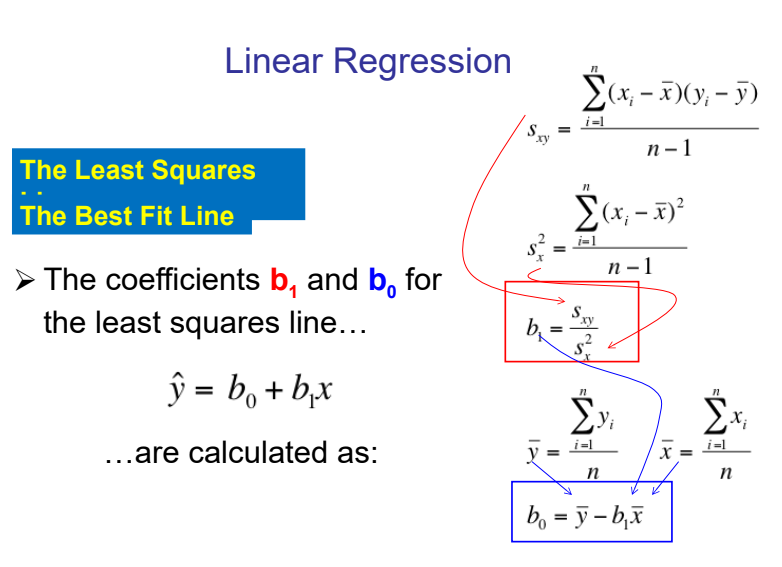

In [33]:
def get_regression_coefficient(x,y):
    """
    calculates the regression coefficents for each feature in x aginst y

    Parameters:
        x (numpy array): Shape (n_samples, n_features)
        y (numpy array): Shape (n_samples,)
        
    Returns:
        b_slope (list): List of slopes for each feature.
        b_intercept (list): List of intercepts for each feature.
        
    """
    x = np.array(x)
    y = np.array(y)
    n = x.shape[0]
    m = x.shape[1]
    y_mean = np.mean(y)
    b_slope = []  #array to store b1 for each feature
    b_intercept = [] #array to store b0 for each feature
    for j in range(m):
        S_xy = 0 #resets the sample covariance for each feature
        S_x2 = 0 #resets the variance for each feature
        x_mean = np.mean(x[: ,j])
        for i in range(n):
            S_xy += (x[i][j]-x_mean) * (y[i]-y_mean)
            S_x2 += (x[i][j]-x_mean) ** 2   
        S_xy = S_xy / (n-1)  #sample covariance calculation 
        S_x2 = S_x2 / (n-1)  #sample variance calculation
        b1 = S_xy / S_x2     #slope (b1)
        b_slope.append(b1)
        b0= y_mean - b1 * x_mean #y-intercepted part (b0)
        b_intercept.append(b0)
    return b_slope , b_intercept

In [34]:
from sklearn.linear_model import LinearRegression

my_slopes, my_intercepts = get_regression_coefficient(X_train, y_train)

sklearn_slopes = []
sklearn_intercepts = []

model = LinearRegression()

num_features = X_train.shape[1]
feature_names = ["Age", "Height", "Weight", "Duration", "Heart Rate", "Body Temp", "Gender male",]

for j in range(num_features):

    x_feature = np.array(X_train)[:, j].reshape(-1, 1)
    model.fit(x_feature, y_train)
    sklearn_slopes.append(model.coef_[0])
    sklearn_intercepts.append(model.intercept_)

# 3. Compare the results
print(f"{'Feature':<10}  | {'Type':<10} | {'Slope':<10} | {'Intercept':<10}")
print("-" * 50)

for i in range(num_features):
    print(f"{feature_names[i]:<11} | Manual     | {my_slopes[i]:.5f}    | {my_intercepts[i]:.5f}")
    print(f"            | Sklearn    | {sklearn_slopes[i]:.5f}    | {sklearn_intercepts[i]:.5f}")
    print("-" * 50)

# Optional: Programmatic check
# Returns True if all numbers are close (within a tiny margin of error)
match_slope = np.allclose(my_slopes, sklearn_slopes)
match_intercept = np.allclose(my_intercepts, sklearn_intercepts)


Feature     | Type       | Slope      | Intercept 
--------------------------------------------------
Age         | Manual     | 9.38039    | 91.09535
            | Sklearn    | 9.38039    | 91.09535
--------------------------------------------------
Height      | Manual     | 0.98277    | 91.11262
            | Sklearn    | 0.98277    | 91.11262
--------------------------------------------------
Weight      | Manual     | 2.04542    | 91.11347
            | Sklearn    | 2.04542    | 91.11347
--------------------------------------------------
Duration    | Manual     | 58.65577    | 91.61174
            | Sklearn    | 58.65577    | 91.61174
--------------------------------------------------
Heart Rate  | Manual     | 55.04457    | 91.48042
            | Sklearn    | 55.04457    | 91.48042
--------------------------------------------------
Body Temp   | Manual     | 51.23276    | 91.53177
            | Sklearn    | 51.23276    | 91.53177
-------------------------------------------------

In [35]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_with_const).fit()

print(model_sm.summary())

print('-'*95)
print(f"R-squared: {model_sm.rsquared:.4f} (Variance explained by the model)")
print(f"F-statistic Prob (p-value): {model_sm.f_pvalue:.4g} (Significance of the overall model)")

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                 4.821e+04
Date:                Wed, 31 Dec 2025   Prob (F-statistic):               0.00
Time:                        07:08:01   Log-Likelihood:                -44879.
No. Observations:               11692   AIC:                         8.977e+04
Df Residuals:                   11684   BIC:                         8.983e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          92.2875      0.202    456.328      

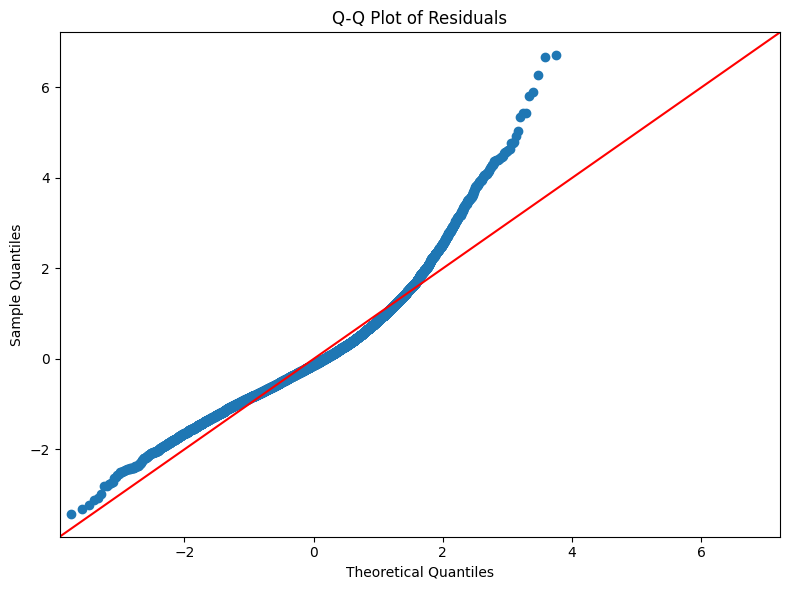

In [36]:
def plot_multivariable_diagnostics(model_result):
    """
    Generates a Q-Q Plot for the Multivariable Regression Model
    using a fitted statsmodels OLS result object.
    
    Parameters:
        model_result: The result object returned by sm.OLS(...).fit()
    """
    
    # 1. Extract residuals
    residuals = model_result.resid
    
    # 2. Create the plot
    # figsize controls the size (Width, Height)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 3. Plot: Q-Q Plot
    # We pass 'ax=ax' to draw it on our specific figure
    sm.qqplot(residuals, line='45', fit=True, ax=ax)
    
    ax.set_title('Q-Q Plot of Residuals')
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_multivariable_diagnostics(model_sm)

--- MODEL ACCURACY TESTING (Test Set) ---
R-squared: 0.9667
MAE:  8.4025 Calories
RMSE: 11.4673 Calories


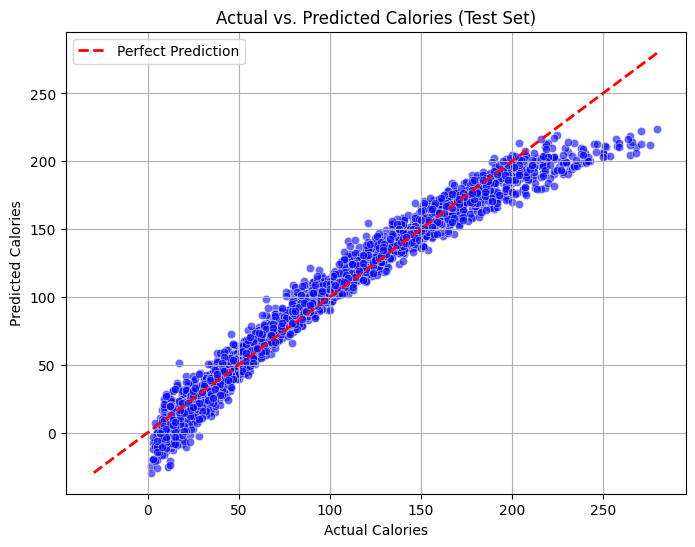

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def test_model_accuracy(model_result, X_test, y_test):
    """
    Tests the statsmodels OLS result on the test set and prints accuracy metrics.
    
    Parameters:
        model_result: The fitted statsmodels OLS result (model_sm).
        X_test: The test features (original, without constant).
        y_test: The true target values for the test set.
    """
    print("--- MODEL ACCURACY TESTING (Test Set) ---")
    
    # 1. Prepare Data: Add constant to X_test (Required for statsmodels)
    # If we don't do this, the math will be wrong because the model expects an intercept column.
    X_test_with_const = sm.add_constant(X_test)
    
    # 2. Make Predictions
    y_pred = model_result.predict(X_test_with_const)
    
    # 3. Calculate Metrics
    # R-squared: How much variance the model explains (1.0 is perfect)
    r2 = r2_score(y_test, y_pred)
    
    # MAE: The average absolute error (in Calories)
    mae = mean_absolute_error(y_test, y_pred)
    
    # RMSE: The root mean squared error (punishes large errors more)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # 4. Print Results
    print(f"R-squared: {r2:.4f}")
    print(f"MAE:  {mae:.4f} Calories")
    print(f"RMSE: {rmse:.4f} Calories")
    
    # 5. Visual Check: Actual vs. Predicted Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
    
    # Add a perfect prediction line (Red diagonal)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    
    plt.title('Actual vs. Predicted Calories (Test Set)')
    plt.xlabel('Actual Calories')
    plt.ylabel('Predicted Calories')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- HOW TO RUN IT ---
# Pass your fitted 'model_sm' and the test data
test_model_accuracy(model_sm, X_test, y_test)